# TAREA 3: REGRESIÓN MULTIVARIADA

## Introducción

Este ejercicio busca desarrollar un análisis completo de regresión múltiple para explicar la variabilidad de una variable respuesta crítica de calidad de energía a partir de variables explicativas seleccionadas mediante la metodología de prognosis industrial. El análisis sigue los fundamentos teóricos propuestos por Peña (2002) en su obra *Análisis de Datos Multivariantes*.

## Contexto de la Base de Datos

La base de datos proviene de mediciones de calidad de energía de la Subestación Canaima (1000kVA), recopiladas mediante un analizador de energía marca Circuitor. En las **Tareas 1 y 2** se realizaron:

- **Tarea 1**: Análisis exploratorio, reducción de dimensionalidad mediante ACP y Análisis Factorial, identificación de patrones multivariantes.
- **Tarea 2**: Clustering jerárquico y K-means para identificar grupos, análisis discriminante (LDA/QDA) y modelos no lineales (SVM, Random Forest) para clasificación.

Estos análisis previos revelaron una estructura en los datos y permitieron identificar **variables críticas** mediante una metodología multifactorial que evalúa varianza, estabilidad, tendencia y correlación (según el documento de prognosis industrial).


## Objetivo del Análisis de Regresión Múltiple

Según Peña (2002, Cap. 3.7.2 - Dependencia Lineal), el análisis de regresión múltiple busca establecer una **relación de dependencia lineal** entre una variable respuesta Y y un conjunto de variables explicativas X, con el objetivo de:

1. **Explicar la variabilidad de Y a partir de X**: Cuantificar qué proporción de la variabilidad de Y puede ser explicada por las variables X.

2. **Identificar variables más influyentes**: Determinar qué variables tienen mayor efecto sobre la variable respuesta.

3. **Cuantificar efectos individuales**: Estimar el cambio en Y asociado a un cambio unitario en cada variable X, controlando por las demás.

4. **Predecir valores de Y**: Estimar valores futuros de Y a partir de valores conocidos de X.

### Variable Respuesta Seleccionada: Distorsión Armónica Total en Corriente L1 (IL1 THD)

**Fundamentación:**
- Indicador crítico de calidad de energía eléctrica
- Relacionado directamente con fallas en equipos industriales
- Variabilidad adecuada para modelado estadístico
- Explicable por variables de armónicos, tensiones y corrientes


In [1]:
# === TAREA 3: REGRESIÓN MULTIVARIADA ===
# Carga de librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox

# Modelos lineales
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Modelos no lineales
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import Pipeline

# Intentar importar GAM (puede no estar disponible)
try:
    from pygam import LinearGAM, s, f
    GAM_AVAILABLE = True
except ImportError:
    GAM_AVAILABLE = False
    print("⚠️ pygam no disponible. GAM no se implementará.")

# Estadísticas
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import WLS

# Series temporales (si aplica)
try:
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.stattools import acf, pacf
    ARIMA_AVAILABLE = True
except ImportError:
    ARIMA_AVAILABLE = False

import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("Librerías cargadas correctamente")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn disponible: {True}")
print(f"Statsmodels disponible: {True}")
print(f"GAM disponible: {GAM_AVAILABLE}")
print(f"ARIMA disponible: {ARIMA_AVAILABLE}")


⚠️ pygam no disponible. GAM no se implementará.
Librerías cargadas correctamente
Pandas: 2.3.2
NumPy: 2.2.6
Scikit-learn disponible: True
Statsmodels disponible: True
GAM disponible: False
ARIMA disponible: True


In [2]:
# === Carga y preparación de datos ===
# IMPORTANTE: Eliminamos tensiones entre fases desde el inicio para prevenir multicolinealidad
# Según Peña (2002, Cap. 3.7.3), no deben incluirse variables con dependencia lineal perfecta

# Cargar datos
file_path = "filtered_consolidated_data_cleaned.xlsx"
df = pd.read_excel(file_path)

print(f"Dimensiones del dataset: {df.shape}")

# Mapeo de variables críticas (SIN tensiones entre fases)
# En sistemas trifásicos: L1-L2 + L2-L3 + L3-L1 = 0 (dependencia lineal perfecta)
# Solución: Usar solo tensiones de fase (L1, L2, L3) que son suficientes
variable_mapping = {
    # Variables de armónicos IL1
    'armonicos_il1_armonico_7_il1': 'Armónicos IL1: Armónico 7 (%IL1)',
    'armonicos_il1_armonico_2_il1': 'Armónicos IL1: Armónico 2 (%IL1)',
    'armonicos_il1_armonico_5_il1': 'Armónicos IL1: Armónico 5 (%IL1)',
    'armonicos_il1_armonico_3_il1': 'Armónicos IL1: Armónico 3 (%IL1)',
    
    # Variables de corriente
    'corriente_l1_a': 'Corriente: L1 (A)',
    'corriente_l2_a': 'Corriente: L2 (A)',
    'corriente_l3_a': 'Corriente: L3 (A)',
    
    # Variables de tensión (SOLO tensiones de fase, NO entre fases)
    'tension_l1_v': 'Tensión: L1 (V)',
    'tension_l2_v': 'Tensión: L2 (V)',
    'tension_l3_v': 'Tensión: L3 (V)',
    
    # Variables de armónicos de tensión
    'armonicos_vl1_armonico_5_vl1': 'Armónicos VL1: Armónico 5 (%VL1)',
    'armonicos_vl2_armonico_5_vl2': 'Armónicos VL2: Armónico 5 (%VL2)',
    'armonicos_vl3_armonico_5_vl3': 'Armónicos VL3: Armónico 5 (%VL3)',
    
    # Variable respuesta (THD)
    'distorsion_armonica_il1_i_thd': 'Distorsión armónica: IL1 (%I THD)'
}

# Variables explicativas (excluyendo la variable respuesta)
X_vars = {k: v for k, v in variable_mapping.items() if k != 'distorsion_armonica_il1_i_thd'}
Y_var = variable_mapping['distorsion_armonica_il1_i_thd']

# Crear DataFrame con variables seleccionadas
X_columns = [v for v in X_vars.values() if v in df.columns]
Y_column = Y_var if Y_var in df.columns else None

if Y_column is None:
    raise ValueError(f"Variable respuesta '{Y_var}' no encontrada en el dataset")

# Filtrar datos completos (sin NaN)
df_reg = df[X_columns + [Y_column]].copy()
df_reg = df_reg.dropna()

print(f"\n=== Preparación de Datos ===")
print(f"Variables explicativas (X): {len(X_columns)}")
print(f"Variable respuesta (Y): {Y_column}")
print(f"Observaciones completas: {len(df_reg)}")
print(f"Observaciones eliminadas (NaN): {len(df) - len(df_reg)}")

# Separar X e Y
X = df_reg[X_columns].values
y = df_reg[Y_column].values
X_names = X_columns

print(f"\nDimensiones finales:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")

# Estadísticas descriptivas
print(f"\n=== Estadísticas Descriptivas de Y ===")
print(df_reg[Y_column].describe())

print(f"\n⚠️ NOTA IMPORTANTE:")
print("Se han ELIMINADO las tensiones entre fases (L1-L2, L2-L3, L3-L1)")
print("debido a dependencia lineal perfecta (L1-L2 + L2-L3 + L3-L1 = 0).")
print("Según Peña (2002, Cap. 3.7.3), esto previene multicolinealidad perfecta.")
print("Las tensiones de fase (L1, L2, L3) son suficientes para caracterizar el sistema.")

# Guardar configuración
import os
OUTPUT_DIR = "/home/elicoubuntu/Desktop/EstadisticaMultivariable/eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


Dimensiones del dataset: (7141, 57)

=== Preparación de Datos ===
Variables explicativas (X): 13
Variable respuesta (Y): Distorsión armónica: IL1 (%I THD)
Observaciones completas: 7141
Observaciones eliminadas (NaN): 0

Dimensiones finales:
  X: (7141, 13)
  y: (7141,)

=== Estadísticas Descriptivas de Y ===
count    7141.000000
mean       10.528904
std         4.803492
min         0.000000
25%         7.200000
50%        12.000000
75%        14.300000
max        19.100000
Name: Distorsión armónica: IL1 (%I THD), dtype: float64

⚠️ NOTA IMPORTANTE:
Se han ELIMINADO las tensiones entre fases (L1-L2, L2-L3, L3-L1)
debido a dependencia lineal perfecta (L1-L2 + L2-L3 + L3-L1 = 0).
Según Peña (2002, Cap. 3.7.3), esto previene multicolinealidad perfecta.
Las tensiones de fase (L1, L2, L3) son suficientes para caracterizar el sistema.


## 2. Comparación de Diferentes Modelos

Según Peña (2002, Cap. 11.6) y los materiales de referencia (Regresión Múltiple Líneal_2025.pptx, Modelos de regresión no lineales_2025.pptx), se compararán diferentes tipos de modelos:

### 2.1 Modelos Lineales
- **OLS (Mínimos Cuadrados Ordinarios)**: Modelo base, según Peña (2002, Cap. 3.7) y Regresión Múltiple Líneal_2025.pptx
- **Modelos con Regularización**: Ridge, Lasso, ElasticNet para manejar multicolinealidad y selección de variables (Peña, Cap. 11.6)

### 2.2 Modelos con Transformaciones
- **Transformación Logarítmica**: Para relaciones no lineales (Peña, Cap. 4.4.1)
- **Transformación Box-Cox**: Transformación óptima para normalidad (Peña, Cap. 4.4.2)

### 2.3 Modelos No Lineales (Modelos de regresión no lineales_2025.pptx)
- **Regresión Polinomial**: Para capturar curvatura en relaciones (grado 2, 3)
- **Splines de Regresión**: Para relaciones no lineales flexibles, dividiendo el rango del predictor en regiones

### 2.4 Criterios de Comparación
Según Peña (2002, Cap. 11.6.1-11.6.3):
- **R² y R² Ajustado**: Miden proporción de varianza explicada
- **AIC (Akaike Information Criterion)**: Penaliza complejidad, menor es mejor
- **BIC (Bayesian Information Criterion)**: Penalización más fuerte, menor es mejor



In [3]:
# === Modelo 1: OLS (Mínimos Cuadrados Ordinarios) ===
# Fundamentación: Peña (2002, Cap. 3.7) - Regresión Múltiple Líneal_2025.pptx

print("=" * 80)
print("MODELO 1: REGRESIÓN MÚLTIPLE OLS")
print("=" * 80)
print("\nSegún Peña (2002, Cap. 3.7), el modelo OLS es el punto de partida")
print("para el análisis de regresión múltiple.\n")

# Usar statsmodels para obtener estadísticas completas
X_with_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_with_const).fit()

print(model_ols.summary())

# Extraer métricas clave
r2_ols = model_ols.rsquared
r2_adj_ols = model_ols.rsquared_adj
aic_ols = model_ols.aic
bic_ols = model_ols.bic

print(f"\n=== Métricas del Modelo OLS ===")
print(f"R²: {r2_ols:.6f}")
print(f"R² Ajustado: {r2_adj_ols:.6f}")
print(f"AIC: {aic_ols:.2f}")
print(f"BIC: {bic_ols:.2f}")
print(f"F-statistic: {model_ols.fvalue:.4f}")
print(f"Prob (F-statistic): {model_ols.f_pvalue:.2e}")

# Guardar coeficientes
coef_ols = pd.DataFrame({
    'Variable': ['Intercepto'] + X_names,
    'Coeficiente': np.array(model_ols.params),
    'Std Error': np.array(model_ols.bse),
    't-value': np.array(model_ols.tvalues),
    'P>|t|': np.array(model_ols.pvalues),
    'Significativo': ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '' 
                     for p in model_ols.pvalues]
})

print(f"\n=== Coeficientes del Modelo OLS ===")
print(coef_ols.to_string(index=False))

coef_ols.to_csv(os.path.join(OUTPUT_DIR, "regression_ols_coefficients.csv"), index=False)
print(f"\nCoeficientes guardados en: regression_ols_coefficients.csv")


MODELO 1: REGRESIÓN MÚLTIPLE OLS

Según Peña (2002, Cap. 3.7), el modelo OLS es el punto de partida
para el análisis de regresión múltiple.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 8.355e+04
Date:                Sun, 09 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:46:52   Log-Likelihood:                -3368.2
No. Observations:                7141   AIC:                             6764.
Df Residuals:                    7127   BIC:                             6861.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025   

In [4]:
# === Modelo 2: Transformación Logarítmica ===
# Fundamentación: Peña (2002, Cap. 4.4.1) - Modelos de regresión no lineales_2025.pptx

print("=" * 80)
print("MODELO 2: TRANSFORMACIÓN LOGARÍTMICA")
print("=" * 80)
print("\nSegún Peña (2002, Cap. 4.4.1), la transformación logarítmica")
print("es útil para relaciones no lineales.\n")

# Verificar que no haya valores negativos (ceros están permitidos con log(y+1))
if (y >= 0).all():
    # Usar log(y+1) para manejar ceros: log(0+1) = log(1) = 0
    y_log = np.log(y + 1)
    
    print(f"Valores en Y: Total={len(y)}, Ceros={(y == 0).sum()} ({(y == 0).sum()/len(y)*100:.2f}%)")
    print(f"Transformación aplicada: log(y + 1) para manejar ceros\n")
    
    # Aplicar log solo a variables sin valores negativos
    X_log = X.copy()
    X_has_negative = (X < 0).any(axis=0)
    for i, has_neg in enumerate(X_has_negative):
        if not has_neg:
            X_log[:, i] = np.log(X[:, i] + 1)
    
    X_log_with_const = sm.add_constant(X_log)
    model_log = sm.OLS(y_log, X_log_with_const).fit()
    
    r2_log = model_log.rsquared
    r2_adj_log = model_log.rsquared_adj
    aic_log = model_log.aic
    bic_log = model_log.bic
    
    print(f"R²: {r2_log:.6f}")
    print(f"R² Ajustado: {r2_adj_log:.6f}")
    print(f"AIC: {aic_log:.2f}")
    print(f"BIC: {bic_log:.2f}")
    
    y_log_available = True
else:
    print("⚠️ No se puede aplicar transformación logarítmica: Y tiene valores negativos")
    print(f"   Valores negativos: {(y < 0).sum()}")
    r2_log = r2_adj_log = aic_log = bic_log = np.nan
    y_log_available = False

# === Modelo 3: Transformación Box-Cox / Yeo-Johnson ===
# Fundamentación: Peña (2002, Cap. 4.4.2)
# NOTA: Box-Cox requiere valores > 0. Si hay ceros, usar Yeo-Johnson

print("\n" + "=" * 80)
print("MODELO 3: TRANSFORMACIÓN BOX-COX / YEO-JOHNSON")
print("=" * 80)
print("\nSegún Peña (2002, Cap. 4.4.2), Box-Cox encuentra la transformación")
print("óptima para normalidad. Si hay ceros, se usa Yeo-Johnson (equivalente).\n")

# Verificar si hay ceros o valores no positivos
has_zeros = (y == 0).any()
has_negatives = (y < 0).any()

if has_zeros or has_negatives:
    # Usar Yeo-Johnson que maneja valores no positivos
    print(f"⚠️ Y tiene valores cero o negativos:")
    print(f"   Ceros: {(y == 0).sum()} ({(y == 0).sum()/len(y)*100:.2f}%)")
    print(f"   Negativos: {(y < 0).sum()} ({(y < 0).sum()/len(y)*100:.2f}%)")
    print("   Usando Yeo-Johnson (equivalente a Box-Cox pero permite valores no positivos)\n")
    
    from scipy.stats import yeojohnson
    y_transformed, lambda_transformed = yeojohnson(y)
    print(f"Parámetro lambda óptimo (Yeo-Johnson): {lambda_transformed:.4f}")
    
    X_transformed_with_const = sm.add_constant(X)
    model_transformed = sm.OLS(y_transformed, X_transformed_with_const).fit()
    
    r2_boxcox = model_transformed.rsquared
    r2_adj_boxcox = model_transformed.rsquared_adj
    aic_boxcox = model_transformed.aic
    bic_boxcox = model_transformed.bic
    
    print(f"R²: {r2_boxcox:.6f}")
    print(f"R² Ajustado: {r2_adj_boxcox:.6f}")
    print(f"AIC: {aic_boxcox:.2f}")
    print(f"BIC: {bic_boxcox:.2f}")
    
    y_boxcox_available = True
    lambda_boxcox = lambda_transformed
    transformation_type = "Yeo-Johnson"
else:
    # Usar Box-Cox estándar (todos los valores son positivos)
    y_boxcox, lambda_boxcox = boxcox(y)
    print(f"Parámetro lambda óptimo (Box-Cox): {lambda_boxcox:.4f}")
    
    X_boxcox_with_const = sm.add_constant(X)
    model_boxcox = sm.OLS(y_boxcox, X_boxcox_with_const).fit()
    
    r2_boxcox = model_boxcox.rsquared
    r2_adj_boxcox = model_boxcox.rsquared_adj
    aic_boxcox = model_boxcox.aic
    bic_boxcox = model_boxcox.bic
    
    print(f"R²: {r2_boxcox:.6f}")
    print(f"R² Ajustado: {r2_adj_boxcox:.6f}")
    print(f"AIC: {aic_boxcox:.2f}")
    print(f"BIC: {bic_boxcox:.2f}")
    
    y_boxcox_available = True
    transformation_type = "Box-Cox"

print(f"\nTipo de transformación aplicada: {transformation_type}")


MODELO 2: TRANSFORMACIÓN LOGARÍTMICA

Según Peña (2002, Cap. 4.4.1), la transformación logarítmica
es útil para relaciones no lineales.

Valores en Y: Total=7141, Ceros=413 (5.78%)
Transformación aplicada: log(y + 1) para manejar ceros

R²: 0.978235
R² Ajustado: 0.978196
AIC: -12218.28
BIC: -12122.05

MODELO 3: TRANSFORMACIÓN BOX-COX / YEO-JOHNSON

Según Peña (2002, Cap. 4.4.2), Box-Cox encuentra la transformación
óptima para normalidad. Si hay ceros, se usa Yeo-Johnson (equivalente).

⚠️ Y tiene valores cero o negativos:
   Ceros: 413 (5.78%)
   Negativos: 0 (0.00%)
   Usando Yeo-Johnson (equivalente a Box-Cox pero permite valores no positivos)

Parámetro lambda óptimo (Yeo-Johnson): 1.2482
R²: 0.995062
R² Ajustado: 0.995053
AIC: 12735.77
BIC: 12832.00

Tipo de transformación aplicada: Yeo-Johnson


In [5]:
# === Modelo 4: Regresión Polinomial ===
# Fundamentación: Modelos de regresión no lineales_2025.pptx

print("=" * 80)
print("MODELO 4: REGRESIÓN POLINOMIAL")
print("=" * 80)
print("\nLa regresión polinomial añade curvatura al modelo introduciendo")
print("predictores elevados a distintas potencias (Modelos de regresión no lineales_2025.pptx).\n")

# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Polinomial grado 2
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

model_poly2 = LinearRegression()
model_poly2.fit(X_train_poly2, y_train)
y_pred_poly2 = model_poly2.predict(X_test_poly2)

r2_poly2 = r2_score(y_test, y_pred_poly2)
mse_poly2 = mean_squared_error(y_test, y_pred_poly2)

# Calcular AIC/BIC aproximados
n = len(y_train)
k_poly2 = X_train_poly2.shape[1] + 1
aic_poly2 = n * np.log(mse_poly2) + 2 * k_poly2
bic_poly2 = n * np.log(mse_poly2) + k_poly2 * np.log(n)

print(f"Polinomial Grado 2:")
print(f"  R² Test: {r2_poly2:.6f}")
print(f"  AIC (aprox): {aic_poly2:.2f}")
print(f"  BIC (aprox): {bic_poly2:.2f}")
print(f"  Variables: {k_poly2 - 1}")

# Polinomial grado 3
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

model_poly3 = LinearRegression()
model_poly3.fit(X_train_poly3, y_train)
y_pred_poly3 = model_poly3.predict(X_test_poly3)

r2_poly3 = r2_score(y_test, y_pred_poly3)
mse_poly3 = mean_squared_error(y_test, y_pred_poly3)

k_poly3 = X_train_poly3.shape[1] + 1
aic_poly3 = n * np.log(mse_poly3) + 2 * k_poly3
bic_poly3 = n * np.log(mse_poly3) + k_poly3 * np.log(n)

print(f"\nPolinomial Grado 3:")
print(f"  R² Test: {r2_poly3:.6f}")
print(f"  AIC (aprox): {aic_poly3:.2f}")
print(f"  BIC (aprox): {bic_poly3:.2f}")
print(f"  Variables: {k_poly3 - 1}")

# === Modelo 5: Splines de Regresión ===
# Fundamentación: Modelos de regresión no lineales_2025.pptx

print("\n" + "=" * 80)
print("MODELO 5: SPLINES DE REGRESIÓN")
print("=" * 80)
print("\nLos splines permiten relaciones no lineales flexibles dividiendo")
print("el rango del predictor en regiones (Modelos de regresión no lineales_2025.pptx).\n")

# Splines con 5 nudos
spline_transformer = SplineTransformer(n_knots=5, degree=3, include_bias=False)
X_train_spline = spline_transformer.fit_transform(X_train)
X_test_spline = spline_transformer.transform(X_test)

model_spline = LinearRegression()
model_spline.fit(X_train_spline, y_train)
y_pred_spline = model_spline.predict(X_test_spline)

r2_spline = r2_score(y_test, y_pred_spline)
mse_spline = mean_squared_error(y_test, y_pred_spline)

k_spline = X_train_spline.shape[1] + 1
aic_spline = n * np.log(mse_spline) + 2 * k_spline
bic_spline = n * np.log(mse_spline) + k_spline * np.log(n)

print(f"R² Test: {r2_spline:.6f}")
print(f"AIC (aprox): {aic_spline:.2f}")
print(f"BIC (aprox): {bic_spline:.2f}")
print(f"Variables: {k_spline - 1}")

# === Modelo 6: Modelos Aditivos Generalizados (GAM) ===
# Fundamentación: Modelos de regresión no lineales_2025.pptx

print("\n" + "=" * 80)
print("MODELO 6: MODELOS ADITIVOS GENERALIZADOS (GAM)")
print("=" * 80)
print("\nLos GAM permiten modelar relaciones no lineales múltiples")
print("(Modelos de regresión no lineales_2025.pptx).\n")

if GAM_AVAILABLE:
    try:
        # GAM con splines suaves para cada variable
        # Nota: pygam requiere que especifiquemos el número de variables
        gam = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9) + s(10) + s(11))
        gam.fit(X_train, y_train)
        y_pred_gam = gam.predict(X_test)
        
        r2_gam = r2_score(y_test, y_pred_gam)
        mse_gam = mean_squared_error(y_test, y_pred_gam)
        
        k_gam = len(X_names) + 1
        aic_gam = n * np.log(mse_gam) + 2 * k_gam
        bic_gam = n * np.log(mse_gam) + k_gam * np.log(n)
        
        print(f"R² Test: {r2_gam:.6f}")
        print(f"AIC (aprox): {aic_gam:.2f}")
        print(f"BIC (aprox): {bic_gam:.2f}")
        
        gam_available = True
    except Exception as e:
        print(f"⚠️ Error al ajustar GAM: {e}")
        r2_gam = aic_gam = bic_gam = np.nan
        gam_available = False
else:
    print("⚠️ GAM no disponible (pygam no instalado)")
    r2_gam = aic_gam = bic_gam = np.nan
    gam_available = False


MODELO 4: REGRESIÓN POLINOMIAL

La regresión polinomial añade curvatura al modelo introduciendo
predictores elevados a distintas potencias (Modelos de regresión no lineales_2025.pptx).

Polinomial Grado 2:
  R² Test: 0.999872
  AIC (aprox): -32847.28
  BIC (aprox): -32149.00
  Variables: 104

Polinomial Grado 3:
  R² Test: 0.999934
  AIC (aprox): -35740.91
  BIC (aprox): -32016.73
  Variables: 559

MODELO 5: SPLINES DE REGRESIÓN

Los splines permiten relaciones no lineales flexibles dividiendo
el rango del predictor en regiones (Modelos de regresión no lineales_2025.pptx).

R² Test: 0.999193
AIC (aprox): -22389.97
BIC (aprox): -21864.60
Variables: 78

MODELO 6: MODELOS ADITIVOS GENERALIZADOS (GAM)

Los GAM permiten modelar relaciones no lineales múltiples
(Modelos de regresión no lineales_2025.pptx).

⚠️ GAM no disponible (pygam no instalado)


In [6]:
# === Modelo 7: Modelos con Regularización ===
# Fundamentación: Peña (2002, Cap. 11.6) - Regresión Múltiple Líneal_2025.pptx

print("=" * 80)
print("MODELO 7: MODELOS CON REGULARIZACIÓN")
print("=" * 80)
print("\nSegún Peña (2002, Cap. 11.6), la regularización es útil para")
print("manejar multicolinealidad y selección de variables.\n")

# Estandarizar para regularización
scaler_reg = StandardScaler()
X_train_std = scaler_reg.fit_transform(X_train)
X_test_std = scaler_reg.transform(X_test)

# Optimizar con validación cruzada (según Regresión Múltiple Líneal_2025.pptx)
alphas_ridge = [0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
ridge_cv = RidgeCV(alphas=alphas_ridge, cv=5, scoring='r2')
ridge_cv.fit(X_train_std, y_train)
best_alpha_ridge = ridge_cv.alpha_

alphas_lasso = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
lasso_cv = LassoCV(alphas=alphas_lasso, cv=5, max_iter=2000, random_state=42)
lasso_cv.fit(X_train_std, y_train)
best_alpha_lasso = lasso_cv.alpha_

elastic_cv = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9], alphas=alphas_lasso, 
                         cv=5, max_iter=2000, random_state=42)
elastic_cv.fit(X_train_std, y_train)
best_alpha_elastic = elastic_cv.alpha_
best_l1_ratio = elastic_cv.l1_ratio_

print(f"Mejor alpha Ridge (CV): {best_alpha_ridge:.2f}")
print(f"Mejor alpha Lasso (CV): {best_alpha_lasso:.2f}")
print(f"Mejor alpha ElasticNet (CV): {best_alpha_elastic:.2f}, l1_ratio: {best_l1_ratio:.2f}")

# Evaluar modelos optimizados
ridge_best = Ridge(alpha=best_alpha_ridge)
ridge_best.fit(X_train_std, y_train)
y_pred_ridge = ridge_best.predict(X_test_std)

lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=2000)
lasso_best.fit(X_train_std, y_train)
y_pred_lasso = lasso_best.predict(X_test_std)

elastic_best = ElasticNet(alpha=best_alpha_elastic, l1_ratio=best_l1_ratio, max_iter=2000)
elastic_best.fit(X_train_std, y_train)
y_pred_elastic = elastic_best.predict(X_test_std)

# Métricas
r2_ridge = r2_score(y_test, y_pred_ridge)
r2_lasso = r2_score(y_test, y_pred_lasso)
r2_elastic = r2_score(y_test, y_pred_elastic)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)

# AIC/BIC
k_ridge = len(X_names) + 1
k_lasso = np.sum(np.abs(lasso_best.coef_) > 1e-6) + 1
k_elastic = np.sum(np.abs(elastic_best.coef_) > 1e-6) + 1

aic_ridge = n * np.log(mse_ridge) + 2 * k_ridge
bic_ridge = n * np.log(mse_ridge) + k_ridge * np.log(n)
aic_lasso = n * np.log(mse_lasso) + 2 * k_lasso
bic_lasso = n * np.log(mse_lasso) + k_lasso * np.log(n)
aic_elastic = n * np.log(mse_elastic) + 2 * k_elastic
bic_elastic = n * np.log(mse_elastic) + k_elastic * np.log(n)

print(f"\n=== Resultados ===")
print(f"Ridge: R²={r2_ridge:.6f}, AIC={aic_ridge:.2f}, BIC={bic_ridge:.2f}")
print(f"Lasso: R²={r2_lasso:.6f}, AIC={aic_lasso:.2f}, BIC={bic_lasso:.2f}, Variables={k_lasso-1}")
print(f"ElasticNet: R²={r2_elastic:.6f}, AIC={aic_elastic:.2f}, BIC={bic_elastic:.2f}, Variables={k_elastic-1}")

# Mostrar variables seleccionadas por Lasso
lasso_vars_selected = [X_names[i] for i in range(len(X_names)) 
                       if np.abs(lasso_best.coef_[i]) > 1e-6]
print(f"\nVariables seleccionadas por Lasso: {len(lasso_vars_selected)}/{len(X_names)}")
if len(lasso_vars_selected) > 0:
    print("Variables seleccionadas:")
    for var in lasso_vars_selected:
        idx = X_names.index(var)
        print(f"  - {var}: coef = {lasso_best.coef_[idx]:.4f}")


MODELO 7: MODELOS CON REGULARIZACIÓN

Según Peña (2002, Cap. 11.6), la regularización es útil para
manejar multicolinealidad y selección de variables.

Mejor alpha Ridge (CV): 0.50
Mejor alpha Lasso (CV): 0.01
Mejor alpha ElasticNet (CV): 0.01, l1_ratio: 0.70

=== Resultados ===
Ridge: R²=0.994164, AIC=-11218.01, BIC=-11124.90
Lasso: R²=0.993883, AIC=-10957.21, BIC=-10890.71, Variables=9
ElasticNet: R²=0.993891, AIC=-10964.43, BIC=-10897.92, Variables=9

Variables seleccionadas por Lasso: 9/13
Variables seleccionadas:
  - Armónicos IL1: Armónico 7 (%IL1): coef = 0.0337
  - Armónicos IL1: Armónico 2 (%IL1): coef = 2.5527
  - Armónicos IL1: Armónico 5 (%IL1): coef = 2.5440
  - Armónicos IL1: Armónico 3 (%IL1): coef = 0.2368
  - Corriente: L1 (A): coef = 0.1987
  - Corriente: L2 (A): coef = 0.1508
  - Tensión: L1 (V): coef = -0.1345
  - Tensión: L3 (V): coef = -0.0583
  - Armónicos VL1: Armónico 5 (%VL1): coef = 0.1451


VALIDACIÓN VISUAL: Y OBSERVADO vs Y PREDICHO

Este gráfico muestra qué tan bien el modelo predice los valores observados.
Los puntos cerca de la línea roja (y = x) indican buenas predicciones.

Métricas de Predicción (OLS):
  MAE (Error Absoluto Medio): 0.2502
  RMSE (Raíz del Error Cuadrático Medio): 0.3878
  R²: 0.993481

Estadísticas de Errores de Predicción:
  Media: -0.000000 (debe ser ≈ 0)
  Desviación estándar: 0.3878
  Mínimo: -1.0353
  Máximo: 5.6052


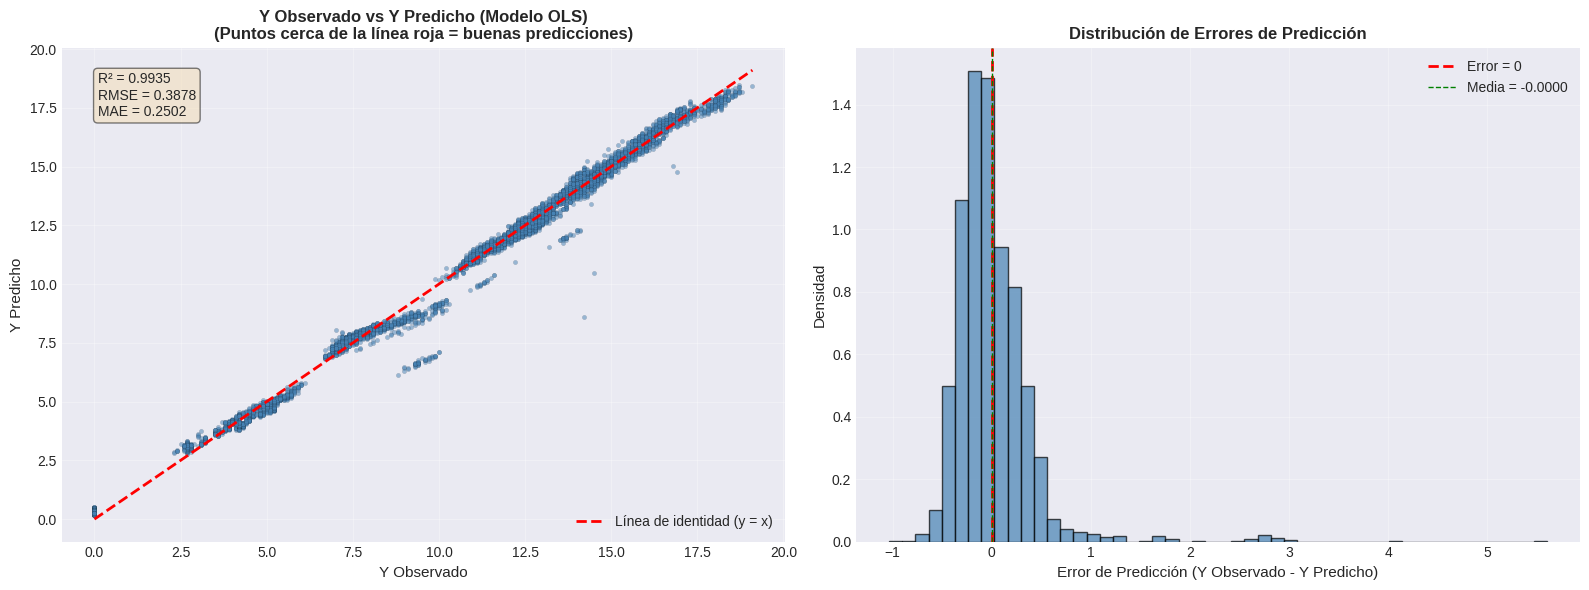


Gráfico guardado y mostrado: regression_y_observed_vs_predicted.png

VALIDACIÓN VISUAL: Y OBSERVADO vs Y PREDICHO (MODELO YEO-JOHNSON)


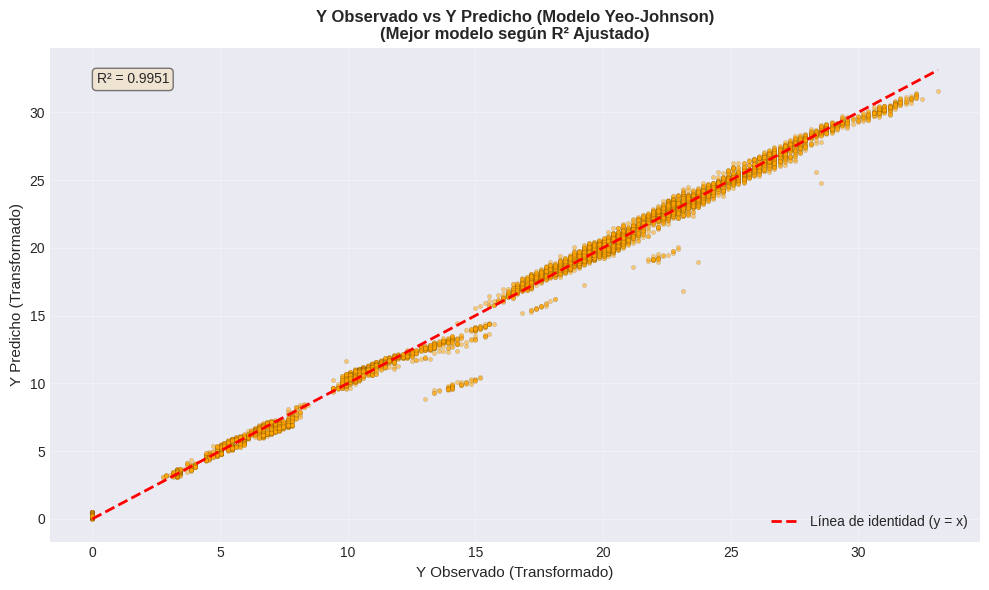

Gráfico guardado y mostrado: regression_y_observed_vs_predicted_yeojohnson.png


In [7]:
# === Gráfico de Validación: Y Observado vs Y Predicho ===
# Fundamentación: Peña (2002, Cap. 10.9) - Validación visual del modelo

print("=" * 80)
print("VALIDACIÓN VISUAL: Y OBSERVADO vs Y PREDICHO")
print("=" * 80)
print("\nEste gráfico muestra qué tan bien el modelo predice los valores observados.")
print("Los puntos cerca de la línea roja (y = x) indican buenas predicciones.\n")

# Obtener valores predichos del modelo OLS
y_pred_ols = model_ols.fittedvalues

# Calcular métricas de predicción
mae_ols = mean_absolute_error(y, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y, y_pred_ols))
r2_ols_manual = r2_score(y, y_pred_ols)

print(f"Métricas de Predicción (OLS):")
print(f"  MAE (Error Absoluto Medio): {mae_ols:.4f}")
print(f"  RMSE (Raíz del Error Cuadrático Medio): {rmse_ols:.4f}")
print(f"  R²: {r2_ols_manual:.6f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Y observado vs Y predicho
axes[0].scatter(y, y_pred_ols, alpha=0.5, s=10, color='steelblue', edgecolors='black', linewidth=0.1)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Línea de identidad (y = x)')
axes[0].set_xlabel('Y Observado', fontsize=11)
axes[0].set_ylabel('Y Predicho', fontsize=11)
axes[0].set_title('Y Observado vs Y Predicho (Modelo OLS)\n(Puntos cerca de la línea roja = buenas predicciones)', 
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Agregar texto con métricas
axes[0].text(0.05, 0.95, f'R² = {r2_ols_manual:.4f}\nRMSE = {rmse_ols:.4f}\nMAE = {mae_ols:.4f}', 
            transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Distribución de errores de predicción
errors_pred = y - y_pred_ols
axes[1].hist(errors_pred, bins=50, density=True, alpha=0.7, edgecolor='black', color='steelblue')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Error = 0')
axes[1].axvline(x=errors_pred.mean(), color='green', linestyle='--', linewidth=1, 
                label=f'Media = {errors_pred.mean():.4f}')
axes[1].set_xlabel('Error de Predicción (Y Observado - Y Predicho)', fontsize=11)
axes[1].set_ylabel('Densidad', fontsize=11)
axes[1].set_title('Distribución de Errores de Predicción', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Estadísticas de errores
print(f"\nEstadísticas de Errores de Predicción:")
print(f"  Media: {errors_pred.mean():.6f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {errors_pred.std():.4f}")
print(f"  Mínimo: {errors_pred.min():.4f}")
print(f"  Máximo: {errors_pred.max():.4f}")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "regression_y_observed_vs_predicted.png"), dpi=300, bbox_inches='tight')
plt.show()  # Mostrar en notebook
plt.close()

print(f"\nGráfico guardado y mostrado: regression_y_observed_vs_predicted.png")

# Opcional: Gráfico para modelo Yeo-Johnson (mejor modelo según R² Ajustado)
if y_boxcox_available:
    print("\n" + "=" * 80)
    print("VALIDACIÓN VISUAL: Y OBSERVADO vs Y PREDICHO (MODELO YEO-JOHNSON)")
    print("=" * 80)
    
    # Obtener valores predichos del modelo transformado
    y_pred_transformed = model_transformed.fittedvalues
    
    # Transformar de vuelta a escala original (si es necesario)
    # Nota: Para Yeo-Johnson, la transformación inversa es compleja
    # Por simplicidad, mostramos en escala transformada
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # En escala transformada
    y_transformed_obs = y_transformed  # Ya calculado en Cell 6
    ax.scatter(y_transformed_obs, y_pred_transformed, alpha=0.5, s=10, 
              color='orange', edgecolors='black', linewidth=0.1)
    ax.plot([y_transformed_obs.min(), y_transformed_obs.max()], 
           [y_transformed_obs.min(), y_transformed_obs.max()], 
           'r--', lw=2, label='Línea de identidad (y = x)')
    ax.set_xlabel('Y Observado (Transformado)', fontsize=11)
    ax.set_ylabel('Y Predicho (Transformado)', fontsize=11)
    ax.set_title('Y Observado vs Y Predicho (Modelo Yeo-Johnson)\n(Mejor modelo según R² Ajustado)', 
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    r2_transformed = r2_score(y_transformed_obs, y_pred_transformed)
    ax.text(0.05, 0.95, f'R² = {r2_transformed:.4f}', 
           transform=ax.transAxes, fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "regression_y_observed_vs_predicted_yeojohnson.png"), 
               dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"Gráfico guardado y mostrado: regression_y_observed_vs_predicted_yeojohnson.png")


COMPARACIÓN DE TODOS LOS MODELOS

Según Peña (2002, Cap. 11.6.2), la selección del mejor modelo
debe balancear ajuste, parsimonia y validez estadística.

             Modelo       R²  R² Ajustado           AIC           BIC         Tipo
                OLS 0.993481     0.993469   6764.416705   6860.647218       Lineal
                Log 0.978235     0.978196 -12218.284785 -12122.054272 Transformado
        Yeo-Johnson 0.995062     0.995053  12735.770205  12832.000718 Transformado
 Polinomial Grado 2 0.999872          NaN -32847.283726 -32148.999653    No Lineal
 Polinomial Grado 3 0.999934          NaN -35740.912409 -32016.730687    No Lineal
            Splines 0.999193          NaN -22389.973775 -21864.598139    No Lineal
     Ridge (α=0.50) 0.994164          NaN -11218.008196 -11124.903653 Regularizado
     Lasso (α=0.01) 0.993883          NaN -10957.210638 -10890.707393 Regularizado
ElasticNet (α=0.01) 0.993891          NaN -10964.426659 -10897.923414 Regularizado

=== Mejor Model

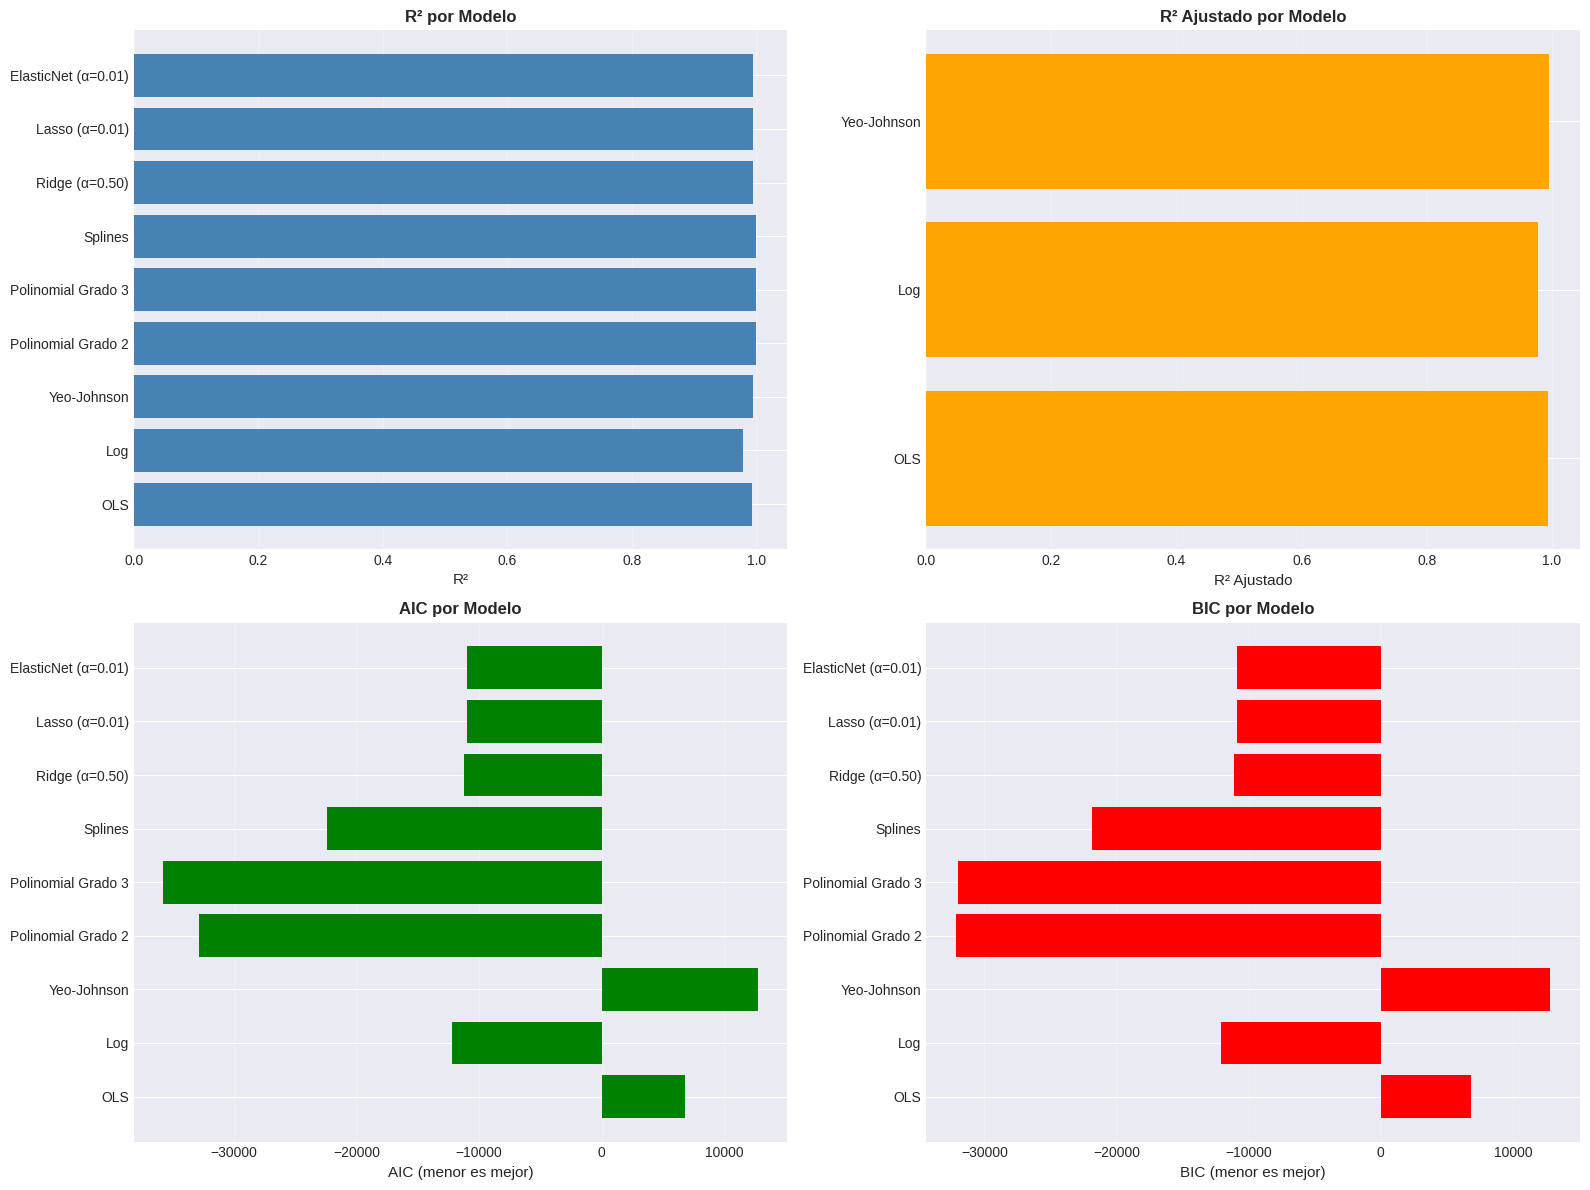


Gráfico guardado y mostrado: regression_all_models_comparison.png


In [8]:
# === Comparación de Todos los Modelos ===
# Fundamentación: Peña (2002, Cap. 11.6.2)

print("=" * 80)
print("COMPARACIÓN DE TODOS LOS MODELOS")
print("=" * 80)
print("\nSegún Peña (2002, Cap. 11.6.2), la selección del mejor modelo")
print("debe balancear ajuste, parsimonia y validez estadística.\n")

# Compilar métricas
models_comparison = []

# OLS
models_comparison.append({
    'Modelo': 'OLS',
    'R²': r2_ols,
    'R² Ajustado': r2_adj_ols,
    'AIC': aic_ols,
    'BIC': bic_ols,
    'Tipo': 'Lineal'
})

# Log
if y_log_available:
    models_comparison.append({
        'Modelo': 'Log',
        'R²': r2_log,
        'R² Ajustado': r2_adj_log,
        'AIC': aic_log,
        'BIC': bic_log,
        'Tipo': 'Transformado'
    })

# Box-Cox / Yeo-Johnson
if y_boxcox_available:
    # Usar el nombre correcto según el tipo de transformación aplicada
    try:
        model_name = transformation_type
    except NameError:
        model_name = 'Box-Cox/Yeo-Johnson'
    models_comparison.append({
        'Modelo': model_name,
        'R²': r2_boxcox,
        'R² Ajustado': r2_adj_boxcox,
        'AIC': aic_boxcox,
        'BIC': bic_boxcox,
        'Tipo': 'Transformado'
    })

# Polinomial
models_comparison.append({
    'Modelo': 'Polinomial Grado 2',
    'R²': r2_poly2,
    'R² Ajustado': np.nan,
    'AIC': aic_poly2,
    'BIC': bic_poly2,
    'Tipo': 'No Lineal'
})

models_comparison.append({
    'Modelo': 'Polinomial Grado 3',
    'R²': r2_poly3,
    'R² Ajustado': np.nan,
    'AIC': aic_poly3,
    'BIC': bic_poly3,
    'Tipo': 'No Lineal'
})

# Splines
models_comparison.append({
    'Modelo': 'Splines',
    'R²': r2_spline,
    'R² Ajustado': np.nan,
    'AIC': aic_spline,
    'BIC': bic_spline,
    'Tipo': 'No Lineal'
})

# GAM
if gam_available:
    models_comparison.append({
        'Modelo': 'GAM',
        'R²': r2_gam,
        'R² Ajustado': np.nan,
        'AIC': aic_gam,
        'BIC': bic_gam,
        'Tipo': 'No Lineal'
    })

# Regularización
models_comparison.append({
    'Modelo': f'Ridge (α={best_alpha_ridge:.2f})',
    'R²': r2_ridge,
    'R² Ajustado': np.nan,
    'AIC': aic_ridge,
    'BIC': bic_ridge,
    'Tipo': 'Regularizado'
})

models_comparison.append({
    'Modelo': f'Lasso (α={best_alpha_lasso:.2f})',
    'R²': r2_lasso,
    'R² Ajustado': np.nan,
    'AIC': aic_lasso,
    'BIC': bic_lasso,
    'Tipo': 'Regularizado'
})

models_comparison.append({
    'Modelo': f'ElasticNet (α={best_alpha_elastic:.2f})',
    'R²': r2_elastic,
    'R² Ajustado': np.nan,
    'AIC': aic_elastic,
    'BIC': bic_elastic,
    'Tipo': 'Regularizado'
})

comparison_df = pd.DataFrame(models_comparison)
print(comparison_df.to_string(index=False))
comparison_df.to_csv(os.path.join(OUTPUT_DIR, "regression_all_models_comparison.csv"), index=False)

# Identificar mejor modelo según cada criterio
print("\n=== Mejor Modelo según cada Criterio ===")
models_with_r2adj = comparison_df[comparison_df['R² Ajustado'].notna()]
if len(models_with_r2adj) > 0:
    best_r2adj_model = models_with_r2adj.loc[models_with_r2adj['R² Ajustado'].idxmax(), 'Modelo']
    best_r2adj_value = models_with_r2adj.loc[models_with_r2adj['R² Ajustado'].idxmax(), 'R² Ajustado']
    print(f"Mayor R² Ajustado: {best_r2adj_model} ({best_r2adj_value:.6f})")

models_with_r2 = comparison_df[comparison_df['R²'].notna()]
if len(models_with_r2) > 0:
    best_r2_model = models_with_r2.loc[models_with_r2['R²'].idxmax(), 'Modelo']
    best_r2_value = models_with_r2.loc[models_with_r2['R²'].idxmax(), 'R²']
    print(f"Mayor R²: {best_r2_model} ({best_r2_value:.6f})")

models_with_aic = comparison_df[comparison_df['AIC'].notna()]
if len(models_with_aic) > 0:
    best_aic_model = models_with_aic.loc[models_with_aic['AIC'].idxmin(), 'Modelo']
    best_aic_value = models_with_aic.loc[models_with_aic['AIC'].idxmin(), 'AIC']
    print(f"Menor AIC: {best_aic_model} ({best_aic_value:.2f})")

models_with_bic = comparison_df[comparison_df['BIC'].notna()]
if len(models_with_bic) > 0:
    best_bic_model = models_with_bic.loc[models_with_bic['BIC'].idxmin(), 'Modelo']
    best_bic_value = models_with_bic.loc[models_with_bic['BIC'].idxmin(), 'BIC']
    print(f"Menor BIC: {best_bic_model} ({best_bic_value:.2f})")

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# R²
axes[0, 0].barh(comparison_df['Modelo'], comparison_df['R²'], color='steelblue')
axes[0, 0].set_xlabel('R²', fontsize=11)
axes[0, 0].set_title('R² por Modelo', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# R² Ajustado (solo modelos que lo tienen)
if len(models_with_r2adj) > 0:
    axes[0, 1].barh(models_with_r2adj['Modelo'], models_with_r2adj['R² Ajustado'], color='orange')
    axes[0, 1].set_xlabel('R² Ajustado', fontsize=11)
    axes[0, 1].set_title('R² Ajustado por Modelo', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='x')
else:
    axes[0, 1].text(0.5, 0.5, 'R² Ajustado no disponible\npara todos los modelos', 
                    ha='center', va='center', transform=axes[0, 1].transAxes, fontsize=12)

# AIC
axes[1, 0].barh(comparison_df['Modelo'], comparison_df['AIC'], color='green')
axes[1, 0].set_xlabel('AIC (menor es mejor)', fontsize=11)
axes[1, 0].set_title('AIC por Modelo', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# BIC
axes[1, 1].barh(comparison_df['Modelo'], comparison_df['BIC'], color='red')
axes[1, 1].set_xlabel('BIC (menor es mejor)', fontsize=11)
axes[1, 1].set_title('BIC por Modelo', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "regression_all_models_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()  # Mostrar en notebook
plt.close()

print(f"\nGráfico guardado y mostrado: regression_all_models_comparison.png")


## 3. Variables Estadísticamente Significativas

Según Peña (2002, Cap. 3.7) y Regresión Múltiple Líneal_2025.pptx, la significancia estadística de los coeficientes se evalúa mediante pruebas t.

### 3.1 Prueba de Hipótesis Individual

Para cada coeficiente βᵢ, se prueba:
- H₀: βᵢ = 0 (la variable no tiene efecto)
- H₁: βᵢ ≠ 0 (la variable tiene efecto)

Se rechaza H₀ si p-valor < 0.05 (significativo al 5%).

### 3.2 Interpretación

- **p < 0.001**: Muy significativo (***)
- **p < 0.01**: Muy significativo (**)
- **p < 0.05**: Significativo (*)
- **p ≥ 0.05**: No significativo


VARIABLES ESTADÍSTICAMENTE SIGNIFICATIVAS

Según Peña (2002, Cap. 3.7), se evalúa la significancia individual
de cada coeficiente mediante pruebas t (p-valores).

Total de variables: 13
Variables significativas (p < 0.05): 13
Variables no significativas: 0

=== Variables Estadísticamente Significativas ===
                        Variable  Coeficiente        P>|t| Significativo
Armónicos IL1: Armónico 7 (%IL1)     0.054601 1.055844e-07           ***
Armónicos IL1: Armónico 2 (%IL1)     0.623649 0.000000e+00           ***
Armónicos IL1: Armónico 5 (%IL1)     0.829296 0.000000e+00           ***
Armónicos IL1: Armónico 3 (%IL1)     0.041917 8.671345e-09           ***
               Corriente: L1 (A)     0.001977 7.137888e-15           ***
               Corriente: L2 (A)    -0.005584 8.637851e-10           ***
               Corriente: L3 (A)     0.007249 3.631743e-15           ***
                 Tensión: L1 (V)    -0.197263 1.545736e-16           ***
                 Tensión: L2 (V)   

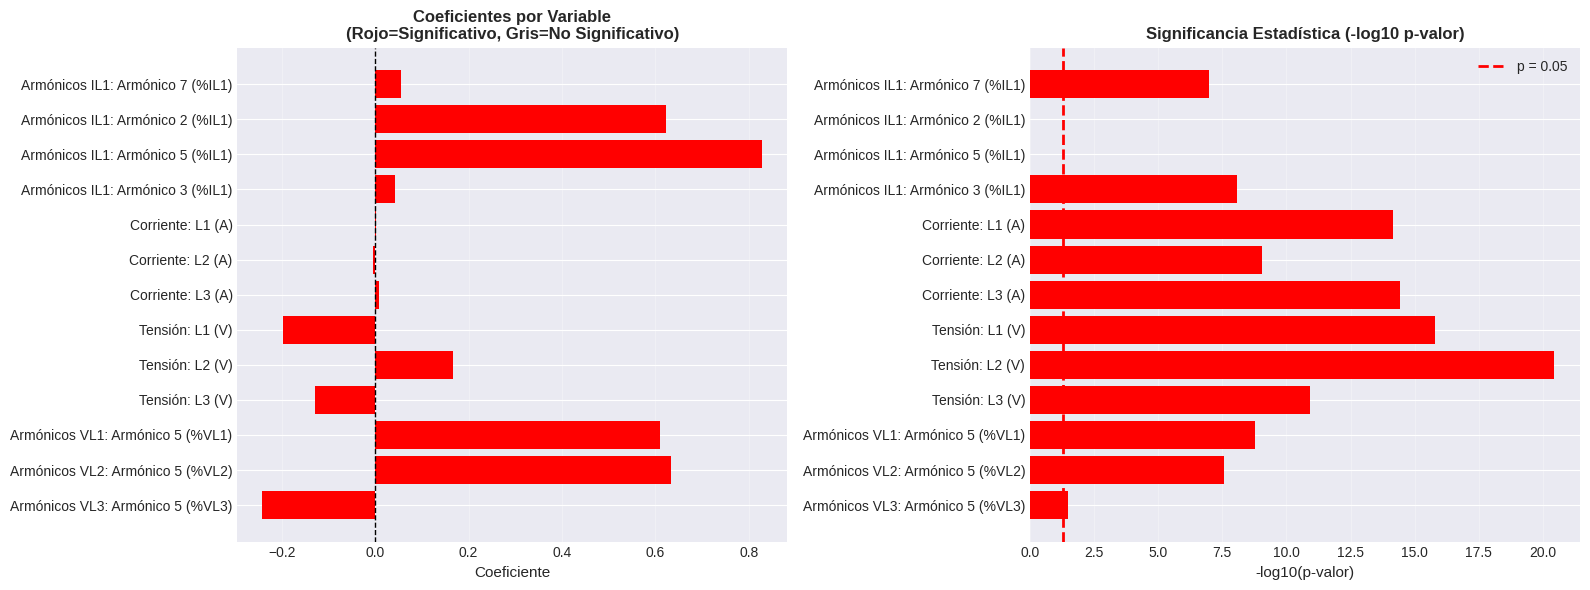


Resultados guardados en: regression_significant_variables.csv


In [9]:
# === Análisis de Significancia Estadística ===
# Fundamentación: Peña (2002, Cap. 3.7) - Regresión Múltiple Líneal_2025.pptx

print("=" * 80)
print("VARIABLES ESTADÍSTICAMENTE SIGNIFICATIVAS")
print("=" * 80)
print("\nSegún Peña (2002, Cap. 3.7), se evalúa la significancia individual")
print("de cada coeficiente mediante pruebas t (p-valores).\n")

# Usar modelo OLS como referencia
significant_vars = coef_ols[coef_ols['P>|t|'] < 0.05].copy()
significant_vars = significant_vars[significant_vars['Variable'] != 'Intercepto']

print(f"Total de variables: {len(X_names)}")
print(f"Variables significativas (p < 0.05): {len(significant_vars)}")
print(f"Variables no significativas: {len(X_names) - len(significant_vars)}")

print("\n=== Variables Estadísticamente Significativas ===")
print(significant_vars[['Variable', 'Coeficiente', 'P>|t|', 'Significativo']].to_string(index=False))

print("\n=== Variables NO Significativas ===")
non_significant = coef_ols[(coef_ols['P>|t|'] >= 0.05) & (coef_ols['Variable'] != 'Intercepto')]
if len(non_significant) > 0:
    print(non_significant[['Variable', 'Coeficiente', 'P>|t|']].to_string(index=False))
else:
    print("Todas las variables son significativas")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coeficientes con significancia
colors = ['red' if p < 0.05 else 'gray' for p in coef_ols.iloc[1:]['P>|t|']]
axes[0].barh(coef_ols.iloc[1:]['Variable'], coef_ols.iloc[1:]['Coeficiente'], color=colors)
axes[0].set_xlabel('Coeficiente', fontsize=11)
axes[0].set_title('Coeficientes por Variable\n(Rojo=Significativo, Gris=No Significativo)', 
                  fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# P-valores
axes[1].barh(coef_ols.iloc[1:]['Variable'], -np.log10(coef_ols.iloc[1:]['P>|t|']), color=colors)
axes[1].axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p = 0.05')
axes[1].set_xlabel('-log10(p-valor)', fontsize=11)
axes[1].set_title('Significancia Estadística (-log10 p-valor)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "regression_significance_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()  # Mostrar en notebook
plt.close()

# Guardar resultados
significant_vars.to_csv(os.path.join(OUTPUT_DIR, "regression_significant_variables.csv"), index=False)
print(f"\nResultados guardados en: regression_significant_variables.csv")


## 4. Variables que Aportan Más al Ajuste Lineal

Según Peña (2002, Cap. 3.7), el aporte de cada variable al ajuste se puede evaluar mediante:

### 4.1 Contribución Marginal al R²

La contribución marginal mide cuánto aumenta el R² al agregar una variable al modelo. Se calcula como:
- R² completo - R² sin la variable

### 4.2 Coeficientes Estandarizados

Los coeficientes estandarizados permiten comparar la magnitud de efectos entre variables con diferentes escalas.

### 4.3 Interpretación

- Variables con mayor contribución marginal: Más importantes para el ajuste
- Variables con coeficientes estandarizados grandes: Mayor efecto sobre Y


CONTRIBUCIÓN MARGINAL DE CADA VARIABLE AL R²

Según Peña (2002, Cap. 3.7), la contribución marginal mide cuánto
aumenta el R² al agregar cada variable al modelo.

                        Variable  R²_Sin_Variable  Contribución_Marginal_R²        P>|t|  Significativo
Armónicos IL1: Armónico 5 (%IL1)         0.955181                  0.038300 0.000000e+00           True
Armónicos IL1: Armónico 2 (%IL1)         0.964955                  0.028526 0.000000e+00           True
                 Tensión: L2 (V)         0.993399                  0.000082 3.738735e-21           True
                 Tensión: L1 (V)         0.993419                  0.000063 1.545736e-16           True
               Corriente: L3 (A)         0.993424                  0.000057 3.631743e-15           True
               Corriente: L1 (A)         0.993426                  0.000056 7.137888e-15           True
                 Tensión: L3 (V)         0.993439                  0.000042 1.206560e-11           True
     

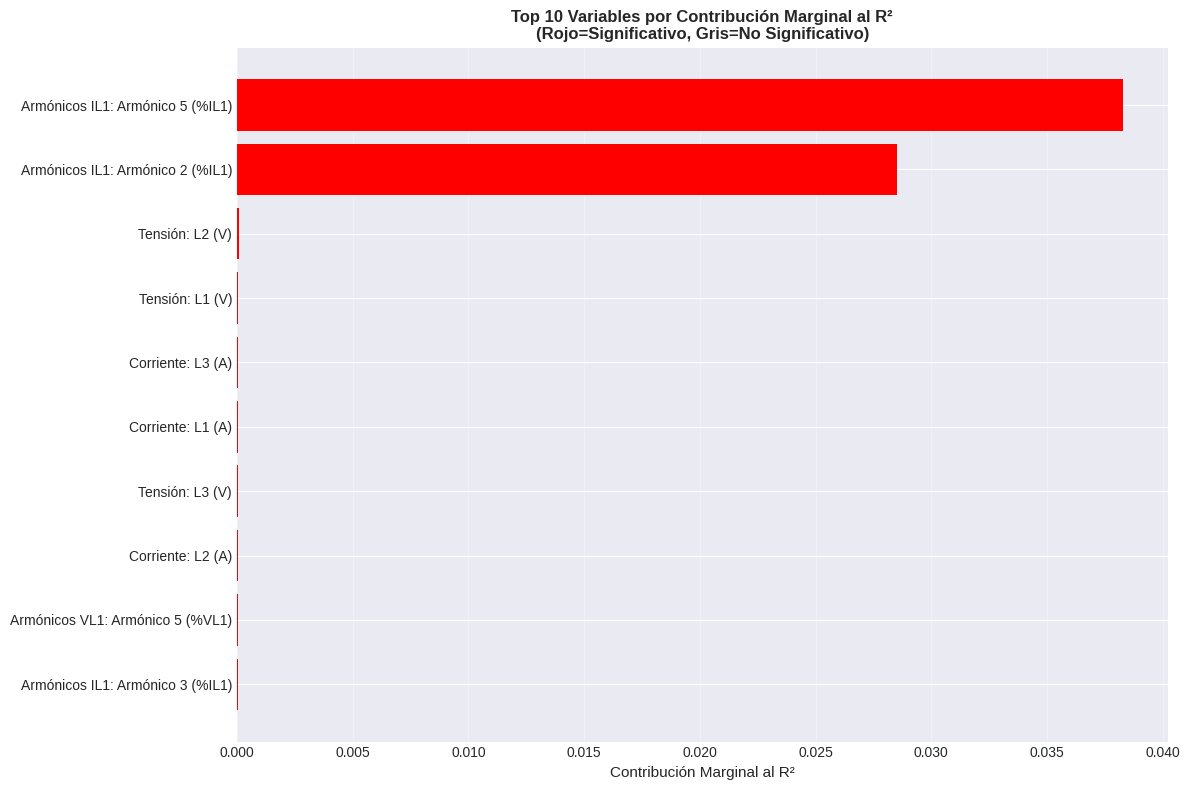


Gráfico guardado y mostrado: regression_marginal_contributions.png


In [10]:
# === Contribución Marginal de Cada Variable al R² ===
# Fundamentación: Peña (2002, Cap. 3.7)

print("=" * 80)
print("CONTRIBUCIÓN MARGINAL DE CADA VARIABLE AL R²")
print("=" * 80)
print("\nSegún Peña (2002, Cap. 3.7), la contribución marginal mide cuánto")
print("aumenta el R² al agregar cada variable al modelo.\n")

# Modelo sin variables (solo intercepto)
X_const_only = sm.add_constant(np.ones((len(y), 1)))
model_base = sm.OLS(y, X_const_only).fit()
r2_base = model_base.rsquared

marginal_contributions = []

for i, var_name in enumerate(X_names):
    # Modelo con todas las variables excepto la i-ésima
    X_without_i = np.delete(X, i, axis=1)
    X_without_i_const = sm.add_constant(X_without_i)
    model_without_i = sm.OLS(y, X_without_i_const).fit()
    r2_without_i = model_without_i.rsquared
    
    # Contribución marginal = R² completo - R² sin esta variable
    marginal_r2 = r2_ols - r2_without_i
    
    marginal_contributions.append({
        'Variable': var_name,
        'R²_Sin_Variable': r2_without_i,
        'Contribución_Marginal_R²': marginal_r2,
        'P>|t|': coef_ols.iloc[i+1]['P>|t|'],
        'Significativo': coef_ols.iloc[i+1]['P>|t|'] < 0.05
    })

marginal_df = pd.DataFrame(marginal_contributions)
marginal_df = marginal_df.sort_values('Contribución_Marginal_R²', ascending=False)

print(marginal_df.to_string(index=False))
marginal_df.to_csv(os.path.join(OUTPUT_DIR, "regression_marginal_contributions.csv"), index=False)

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

top_10 = marginal_df.head(10)
colors = ['red' if sig else 'gray' for sig in top_10['Significativo']]
ax.barh(top_10['Variable'], top_10['Contribución_Marginal_R²'], color=colors)
ax.set_xlabel('Contribución Marginal al R²', fontsize=11)
ax.set_title('Top 10 Variables por Contribución Marginal al R²\n(Rojo=Significativo, Gris=No Significativo)', 
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "regression_marginal_contributions.png"), dpi=300, bbox_inches='tight')
plt.show()  # Mostrar en notebook
plt.close()

print(f"\nGráfico guardado y mostrado: regression_marginal_contributions.png")


COEFICIENTES ESTANDARIZADOS

Los coeficientes estandarizados permiten comparar la magnitud
de efectos entre variables con diferentes escalas.

                        Variable  Coeficiente_Estandarizado        P>|t|
Armónicos IL1: Armónico 2 (%IL1)                   0.555996 0.000000e+00
Armónicos IL1: Armónico 5 (%IL1)                   0.554892 0.000000e+00
               Corriente: L3 (A)                   0.200759 3.631743e-15
               Corriente: L2 (A)                  -0.161993 8.637851e-10
                 Tensión: L1 (V)                  -0.100801 1.545736e-16
                 Tensión: L2 (V)                   0.095544 3.738735e-21
                 Tensión: L3 (V)                  -0.068645 1.206560e-11
Armónicos VL2: Armónico 5 (%VL2)                   0.056189 2.776891e-08
Armónicos VL1: Armónico 5 (%VL1)                   0.044906 1.630205e-09
               Corriente: L1 (A)                   0.042720 7.137888e-15
Armónicos IL1: Armónico 3 (%IL1)                   0.0

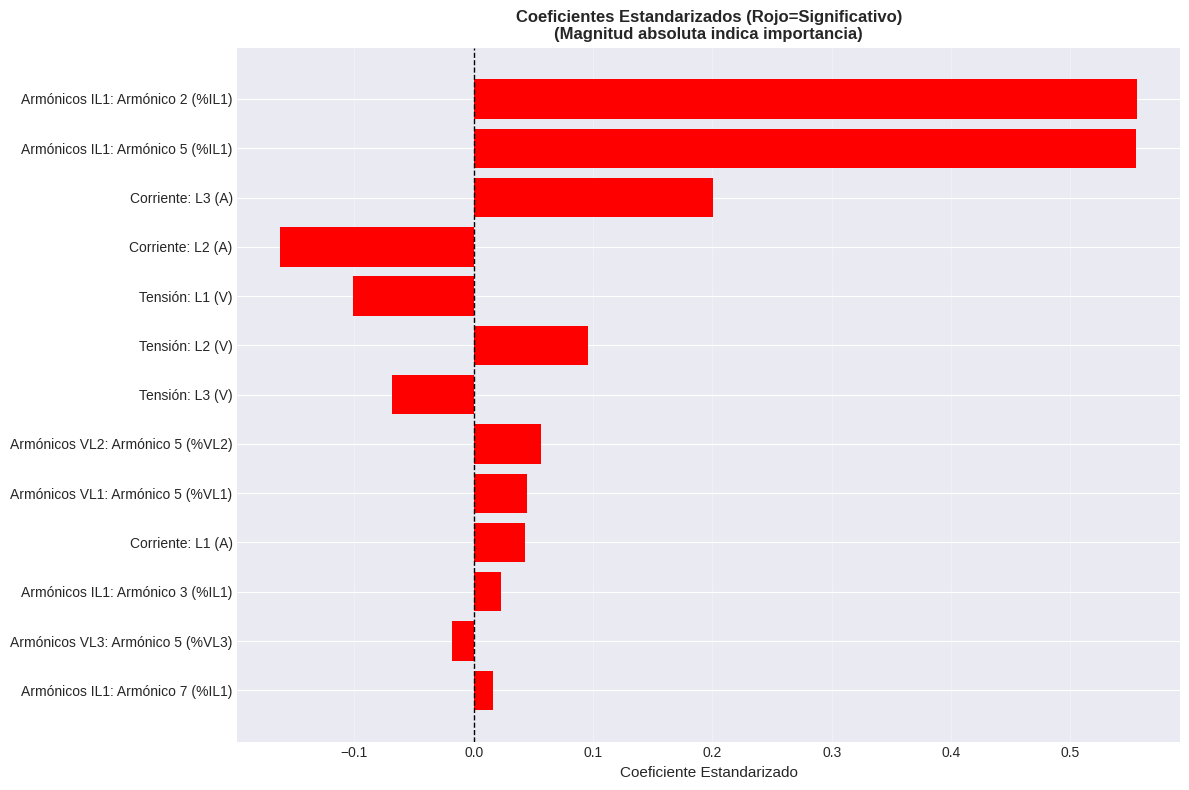


Gráfico guardado y mostrado: regression_standardized_coefficients.png


In [11]:
# === Coeficientes Estandarizados ===
# Fundamentación: Peña (2002, Cap. 3.7)

print("=" * 80)
print("COEFICIENTES ESTANDARIZADOS")
print("=" * 80)
print("\nLos coeficientes estandarizados permiten comparar la magnitud")
print("de efectos entre variables con diferentes escalas.\n")

# Estandarizar variables
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_std = scaler_X.fit_transform(X)
y_std = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Modelo con variables estandarizadas
X_std_with_const = sm.add_constant(X_std)
model_ols_std = sm.OLS(y_std, X_std_with_const).fit()

# Coeficientes estandarizados (excluir intercepto)
coef_std = pd.DataFrame({
    'Variable': X_names,
    'Coeficiente_Estandarizado': np.array(model_ols_std.params[1:]),
    'P>|t|': np.array(model_ols_std.pvalues[1:])
})

# Ordenar por magnitud absoluta
coef_std['Abs_Coef'] = np.abs(coef_std['Coeficiente_Estandarizado'])
coef_std = coef_std.sort_values('Abs_Coef', ascending=False)
coef_std = coef_std.drop('Abs_Coef', axis=1)

print(coef_std.to_string(index=False))
coef_std.to_csv(os.path.join(OUTPUT_DIR, "regression_standardized_coefficients.csv"), index=False)

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

colors = ['red' if p < 0.05 else 'gray' for p in coef_std['P>|t|']]
ax.barh(coef_std['Variable'], coef_std['Coeficiente_Estandarizado'], color=colors)
ax.set_xlabel('Coeficiente Estandarizado', fontsize=11)
ax.set_title('Coeficientes Estandarizados (Rojo=Significativo)\n(Magnitud absoluta indica importancia)', 
             fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "regression_standardized_coefficients.png"), dpi=300, bbox_inches='tight')
plt.show()  # Mostrar en notebook
plt.close()

print(f"\nGráfico guardado y mostrado: regression_standardized_coefficients.png")


## 5. Validación de Supuestos Estadísticos

Según Peña (2002, Caps. 4.4 y 10.9) y Regresión Múltiple Líneal_2025.pptx, el modelo de regresión múltiple requiere el cumplimiento de los siguientes supuestos:

### 5.1 Normalidad de Residuos
- Los residuos deben seguir una distribución normal
- Prueba: Shapiro-Wilk
- Visualización: Q-Q Plot, histograma

### 5.2 Homocedasticidad
- La varianza de los residuos debe ser constante
- Prueba: Breusch-Pagan
- Visualización: Residuos vs valores ajustados

### 5.3 Independencia
- Los residuos deben ser independientes entre sí
- Prueba: Durbin-Watson
- Visualización: Residuos vs orden, ACF

### 5.4 Multicolinealidad
- Las variables explicativas no deben tener dependencia lineal exacta
- Prueba: VIF (Factor de Inflación de la Varianza)
- Visualización: Matriz de correlaciones


VALIDACIÓN DE SUPUESTOS: NORMALIDAD DE RESIDUOS

Según Peña (2002, Cap. 10.9), los residuos deben seguir una
distribución normal para la validez de las pruebas t y F.

Prueba de Shapiro-Wilk:
  Estadístico: 0.756308
  p-valor: 3.61e-73
  ❌ Se rechaza H0: Los residuos NO siguen una distribución normal

Estadísticas descriptivas de residuos:
  Media: -0.000000 (debe ser ≈ 0)
  Desviación estándar: 0.387800
  Asimetría: 3.5864 (normal = 0)
  Curtosis: 25.2145 (normal = 3)


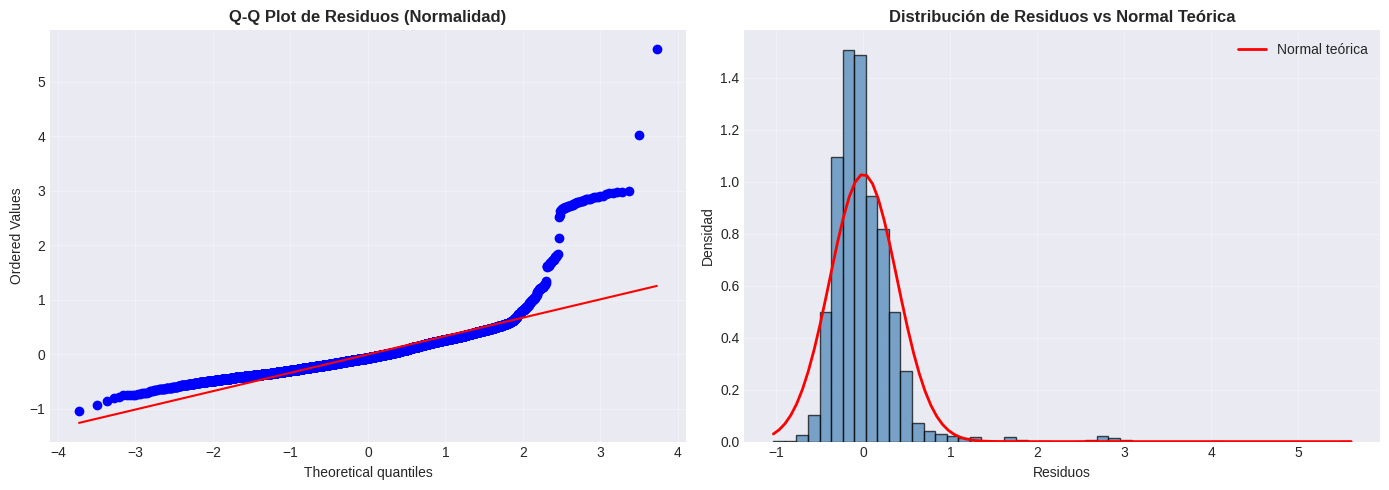


Gráfico guardado y mostrado: regression_normality_diagnostics.png


In [12]:
# === Validación de Supuestos: Normalidad ===
# Fundamentación: Peña (2002, Cap. 10.9) - Regresión Múltiple Líneal_2025.pptx

print("=" * 80)
print("VALIDACIÓN DE SUPUESTOS: NORMALIDAD DE RESIDUOS")
print("=" * 80)
print("\nSegún Peña (2002, Cap. 10.9), los residuos deben seguir una")
print("distribución normal para la validez de las pruebas t y F.\n")

# Obtener residuos del modelo OLS
residuals = model_ols.resid
fitted_values = model_ols.fittedvalues

# Prueba de Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Prueba de Shapiro-Wilk:")
print(f"  Estadístico: {shapiro_stat:.6f}")
print(f"  p-valor: {shapiro_p:.2e}")
if shapiro_p < 0.05:
    print("  ❌ Se rechaza H0: Los residuos NO siguen una distribución normal")
else:
    print("  ✓ No se rechaza H0: Los residuos siguen una distribución normal")

# Estadísticas descriptivas
print(f"\nEstadísticas descriptivas de residuos:")
print(f"  Media: {residuals.mean():.6f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {residuals.std():.6f}")
print(f"  Asimetría: {stats.skew(residuals):.4f} (normal = 0)")
print(f"  Curtosis: {stats.kurtosis(residuals):.4f} (normal = 3)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Histograma con curva normal
axes[1].hist(residuals, bins=50, density=True, alpha=0.7, edgecolor='black', color='steelblue')
axes[1].set_title('Distribución de Residuos vs Normal Teórica', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residuos')
axes[1].set_ylabel('Densidad')
mu, sigma = residuals.mean(), residuals.std()
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
axes[1].plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), 'r-', linewidth=2, label='Normal teórica')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "regression_normality_diagnostics.png"), dpi=300, bbox_inches='tight')
plt.show()  # Mostrar en notebook
plt.close()

print(f"\nGráfico guardado y mostrado: regression_normality_diagnostics.png")


VALIDACIÓN DE SUPUESTOS: HOMOCEDASTICIDAD

Según Peña (2002, Cap. 10.9), la varianza de los residuos debe
ser constante (homocedasticidad).

Prueba de Breusch-Pagan:
  Estadístico: 626.868549
  p-valor: 1.43e-125
  ❌ Se rechaza H0: Los residuos NO son homocedásticos (heterocedasticidad)


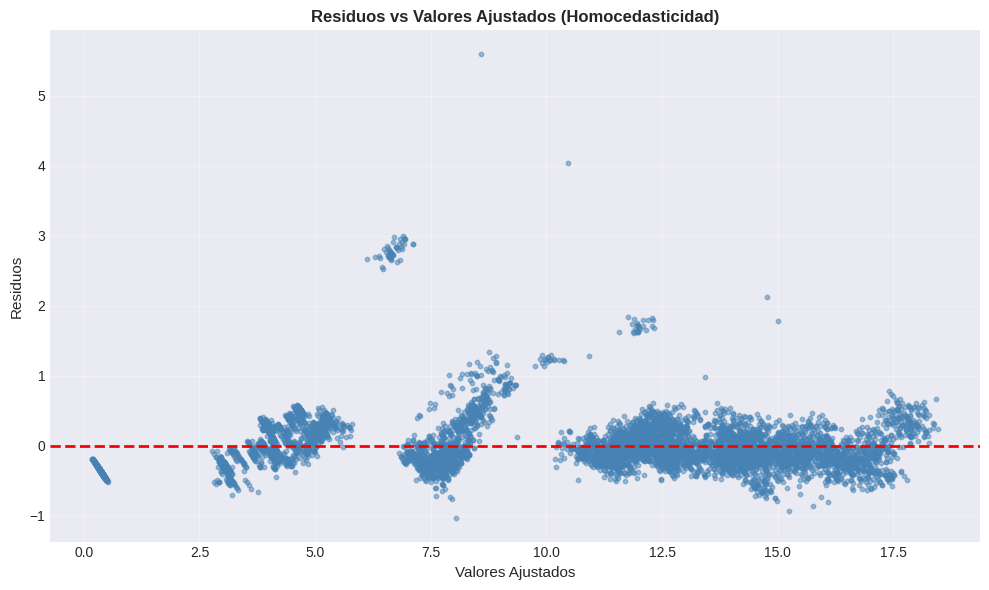


Gráfico guardado y mostrado: regression_homoscedasticity_diagnostics.png


In [13]:
# === Validación de Supuestos: Homocedasticidad ===
# Fundamentación: Peña (2002, Cap. 10.9) - Regresión Múltiple Líneal_2025.pptx

print("=" * 80)
print("VALIDACIÓN DE SUPUESTOS: HOMOCEDASTICIDAD")
print("=" * 80)
print("\nSegún Peña (2002, Cap. 10.9), la varianza de los residuos debe")
print("ser constante (homocedasticidad).\n")

# Prueba de Breusch-Pagan
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_with_const)
print(f"Prueba de Breusch-Pagan:")
print(f"  Estadístico: {bp_stat:.6f}")
print(f"  p-valor: {bp_p:.2e}")
if bp_p < 0.05:
    print("  ❌ Se rechaza H0: Los residuos NO son homocedásticos (heterocedasticidad)")
else:
    print("  ✓ No se rechaza H0: Los residuos son homocedásticos")

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.scatter(fitted_values, residuals, alpha=0.5, s=10, color='steelblue')
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Valores Ajustados', fontsize=11)
ax.set_ylabel('Residuos', fontsize=11)
ax.set_title('Residuos vs Valores Ajustados (Homocedasticidad)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "regression_homoscedasticity_diagnostics.png"), dpi=300, bbox_inches='tight')
plt.show()  # Mostrar en notebook
plt.close()

print(f"\nGráfico guardado y mostrado: regression_homoscedasticity_diagnostics.png")


VALIDACIÓN DE SUPUESTOS: INDEPENDENCIA

Según Peña (2002, Cap. 4.4), los residuos deben ser independientes.

Prueba de Durbin-Watson:
  Estadístico: 0.2627
  Interpretación:
    ❌ Autocorrelación positiva (residuos no independientes)


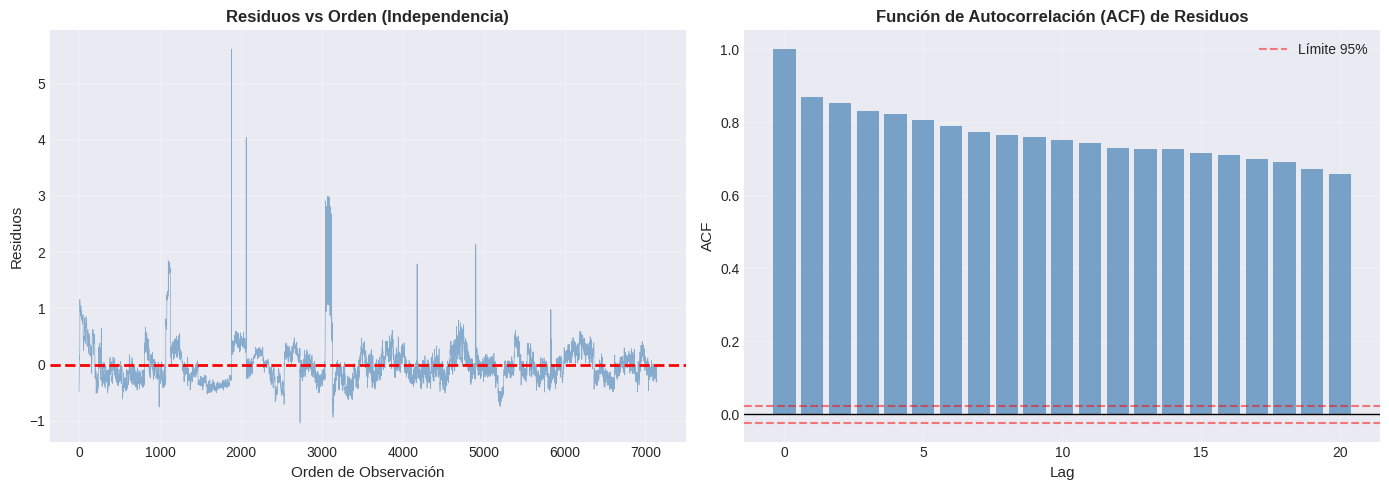


Gráfico guardado y mostrado: regression_independence_diagnostics.png


In [14]:
# === Validación de Supuestos: Independencia ===
# Fundamentación: Peña (2002, Cap. 4.4) - Series de tiempo_2025.pptx

print("=" * 80)
print("VALIDACIÓN DE SUPUESTOS: INDEPENDENCIA")
print("=" * 80)
print("\nSegún Peña (2002, Cap. 4.4), los residuos deben ser independientes.\n")

# Prueba de Durbin-Watson
dw_stat = durbin_watson(residuals)
print(f"Prueba de Durbin-Watson:")
print(f"  Estadístico: {dw_stat:.4f}")
print(f"  Interpretación:")
if dw_stat < 1.5:
    print("    ❌ Autocorrelación positiva (residuos no independientes)")
elif dw_stat > 2.5:
    print("    ❌ Autocorrelación negativa (residuos no independientes)")
else:
    print("    ✓ No hay evidencia de autocorrelación (residuos independientes)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuos vs orden
axes[0].plot(range(len(residuals)), residuals, alpha=0.6, linewidth=0.5, color='steelblue')
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Orden de Observación', fontsize=11)
axes[0].set_ylabel('Residuos', fontsize=11)
axes[0].set_title('Residuos vs Orden (Independencia)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# ACF de residuos (si hay autocorrelación)
if ARIMA_AVAILABLE:
    try:
        acf_residuals = acf(residuals, nlags=20, fft=True)
        axes[1].bar(range(len(acf_residuals)), acf_residuals, alpha=0.7, color='steelblue')
        axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
        axes[1].axhline(y=1.96/np.sqrt(len(residuals)), color='r', linestyle='--', alpha=0.5, label='Límite 95%')
        axes[1].axhline(y=-1.96/np.sqrt(len(residuals)), color='r', linestyle='--', alpha=0.5)
        axes[1].set_xlabel('Lag', fontsize=11)
        axes[1].set_ylabel('ACF', fontsize=11)
        axes[1].set_title('Función de Autocorrelación (ACF) de Residuos', fontsize=12, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    except:
        axes[1].text(0.5, 0.5, 'ACF no disponible', ha='center', va='center', 
                    transform=axes[1].transAxes, fontsize=12)
else:
    axes[1].text(0.5, 0.5, 'ACF no disponible\n(statsmodels.tsa no disponible)', 
                ha='center', va='center', transform=axes[1].transAxes, fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "regression_independence_diagnostics.png"), dpi=300, bbox_inches='tight')
plt.show()  # Mostrar en notebook
plt.close()

print(f"\nGráfico guardado y mostrado: regression_independence_diagnostics.png")


VALIDACIÓN DE SUPUESTOS: MULTICOLINEALIDAD

Según Peña (2002, Cap. 3.7.3), no debe existir multicolinealidad
perfecta. El VIF mide la inflación de varianza debido a correlación.

NOTA: Las tensiones entre fases fueron eliminadas desde el inicio
para prevenir multicolinealidad perfecta.

Factor de Inflación de la Varianza (VIF):
                        Variable          VIF
                 Tensión: L1 (V) 1.829449e+06
                 Tensión: L2 (V) 1.035253e+06
                 Tensión: L3 (V) 1.029319e+06
               Corriente: L2 (A) 6.854880e+03
               Corriente: L3 (A) 6.772553e+03
Armónicos VL2: Armónico 5 (%VL2) 5.251724e+02
Armónicos VL3: Armónico 5 (%VL3) 3.188680e+02
Armónicos VL1: Armónico 5 (%VL1) 3.111578e+02
               Corriente: L1 (A) 1.399360e+02
Armónicos IL1: Armónico 3 (%IL1) 4.461580e+01
Armónicos IL1: Armónico 5 (%IL1) 3.716489e+01
Armónicos IL1: Armónico 7 (%IL1) 3.028466e+01
Armónicos IL1: Armónico 2 (%IL1) 2.511602e+01

Interpretación:
  VIF < 5

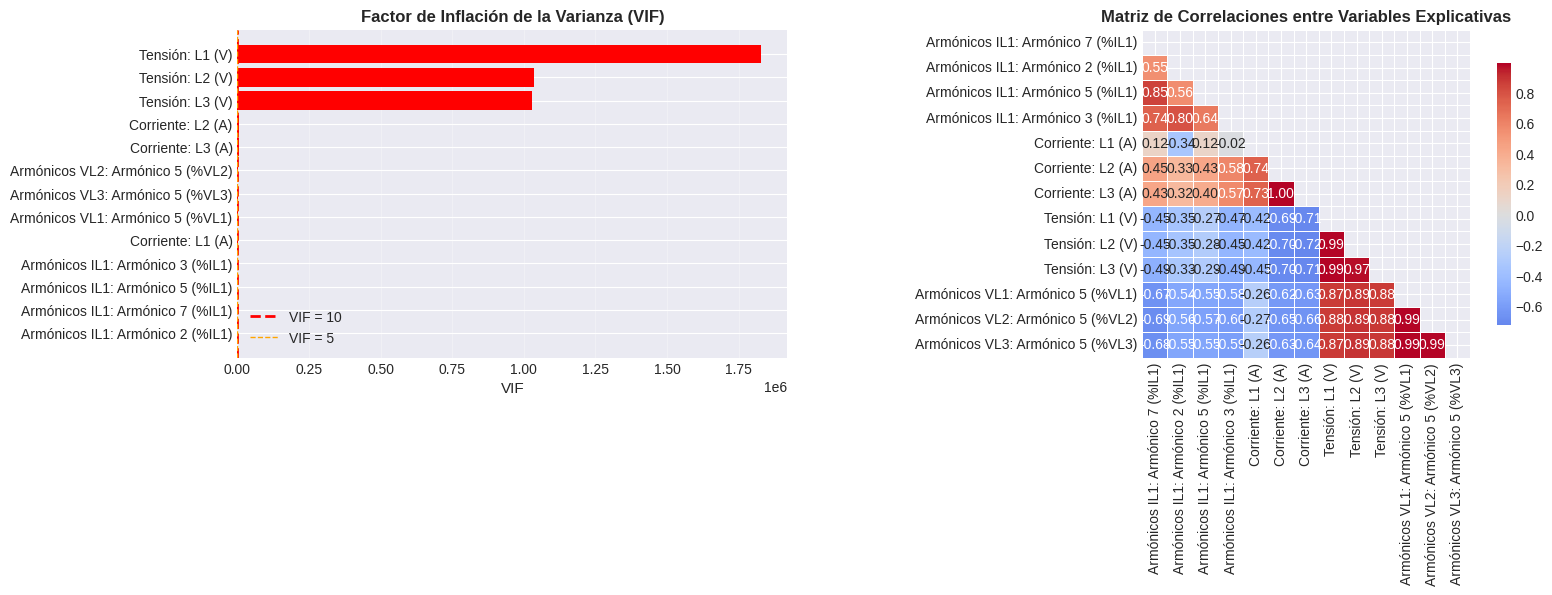


Gráfico guardado y mostrado: regression_multicollinearity_diagnostics.png


In [15]:
# === Validación de Supuestos: Multicolinealidad ===
# Fundamentación: Peña (2002, Cap. 3.7.3) - Regresión Múltiple Líneal_2025.pptx

print("=" * 80)
print("VALIDACIÓN DE SUPUESTOS: MULTICOLINEALIDAD")
print("=" * 80)
print("\nSegún Peña (2002, Cap. 3.7.3), no debe existir multicolinealidad")
print("perfecta. El VIF mide la inflación de varianza debido a correlación.\n")
print("NOTA: Las tensiones entre fases fueron eliminadas desde el inicio")
print("para prevenir multicolinealidad perfecta.\n")

# Calcular VIF
vif_data = []
for i in range(len(X_names)):
    vif_value = variance_inflation_factor(X, i)
    vif_data.append({
        'Variable': X_names[i],
        'VIF': vif_value
    })

vif_df = pd.DataFrame(vif_data)
vif_df = vif_df.sort_values('VIF', ascending=False)

print("Factor de Inflación de la Varianza (VIF):")
print(vif_df.to_string(index=False))
print("\nInterpretación:")
print("  VIF < 5: Multicolinealidad baja")
print("  5 ≤ VIF < 10: Multicolinealidad moderada")
print("  VIF ≥ 10: Multicolinealidad alta (problema)")

high_vif = vif_df[vif_df['VIF'] >= 10]
if len(high_vif) > 0:
    print(f"\n⚠️ Variables con VIF ≥ 10 (multicolinealidad alta):")
    print(high_vif.to_string(index=False))
else:
    print("\n✓ No hay variables con VIF ≥ 10")

vif_df.to_csv(os.path.join(OUTPUT_DIR, "regression_vif.csv"), index=False)

# Matriz de correlaciones
corr_matrix = pd.DataFrame(X, columns=X_names).corr()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# VIF
colors_vif = ['red' if vif >= 10 else 'orange' if vif >= 5 else 'green' for vif in vif_df['VIF']]
axes[0].barh(vif_df['Variable'], vif_df['VIF'], color=colors_vif)
axes[0].axvline(x=10, color='red', linestyle='--', linewidth=2, label='VIF = 10')
axes[0].axvline(x=5, color='orange', linestyle='--', linewidth=1, label='VIF = 5')
axes[0].set_xlabel('VIF', fontsize=11)
axes[0].set_title('Factor de Inflación de la Varianza (VIF)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Matriz de correlaciones
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title('Matriz de Correlaciones entre Variables Explicativas', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "regression_multicollinearity_diagnostics.png"), dpi=300, bbox_inches='tight')
plt.show()  # Mostrar en notebook
plt.close()

print(f"\nGráfico guardado y mostrado: regression_multicollinearity_diagnostics.png")


RESUMEN DE VALIDACIÓN DE SUPUESTOS
         Supuesto        Prueba Estadístico   p-valor Cumple           Interpretación
       Normalidad  Shapiro-Wilk      0.7563  3.61e-73     No     Residuos no normales
 Homocedasticidad Breusch-Pagan    626.8685 1.43e-125     No          Heterocedástico
    Independencia Durbin-Watson      0.2627       N/A     No Autocorrelación presente
Multicolinealidad           VIF  1829449.43       N/A     No   Multicolinealidad alta


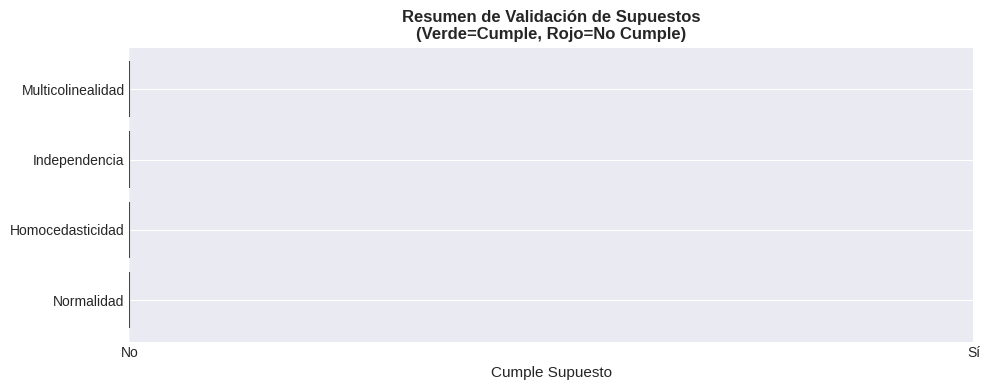


Gráfico guardado y mostrado: regression_assumptions_summary.png


In [16]:
# === Resumen de Validación de Supuestos ===
# Fundamentación: Peña (2002, Cap. 10.9)

print("=" * 80)
print("RESUMEN DE VALIDACIÓN DE SUPUESTOS")
print("=" * 80)

assumptions_summary = pd.DataFrame({
    'Supuesto': ['Normalidad', 'Homocedasticidad', 'Independencia', 'Multicolinealidad'],
    'Prueba': ['Shapiro-Wilk', 'Breusch-Pagan', 'Durbin-Watson', 'VIF'],
    'Estadístico': [f'{shapiro_stat:.4f}', f'{bp_stat:.4f}', f'{dw_stat:.4f}', f'{vif_df["VIF"].max():.2f}'],
    'p-valor': [f'{shapiro_p:.2e}', f'{bp_p:.2e}', 'N/A', 'N/A'],
    'Cumple': [
        'Sí' if shapiro_p >= 0.05 else 'No',
        'Sí' if bp_p >= 0.05 else 'No',
        'Sí' if 1.5 <= dw_stat <= 2.5 else 'No',
        'Sí' if vif_df['VIF'].max() < 10 else 'No'
    ],
    'Interpretación': [
        'Residuos normales' if shapiro_p >= 0.05 else 'Residuos no normales',
        'Homocedástico' if bp_p >= 0.05 else 'Heterocedástico',
        'Independientes' if 1.5 <= dw_stat <= 2.5 else 'Autocorrelación presente',
        'Baja multicolinealidad' if vif_df['VIF'].max() < 10 else 'Multicolinealidad alta'
    ]
})

print(assumptions_summary.to_string(index=False))
assumptions_summary.to_csv(os.path.join(OUTPUT_DIR, "regression_assumptions_summary.csv"), index=False)

# Visualización resumen
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

colors_summary = ['green' if cumple == 'Sí' else 'red' for cumple in assumptions_summary['Cumple']]
ax.barh(assumptions_summary['Supuesto'], [1 if c == 'Sí' else 0 for c in assumptions_summary['Cumple']], 
        color=colors_summary, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Cumple Supuesto', fontsize=11)
ax.set_title('Resumen de Validación de Supuestos\n(Verde=Cumple, Rojo=No Cumple)', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No', 'Sí'])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "regression_assumptions_summary.png"), dpi=300, bbox_inches='tight')
plt.show()  # Mostrar en notebook
plt.close()

print(f"\nGráfico guardado y mostrado: regression_assumptions_summary.png")


In [17]:
# === Conclusiones del Análisis ===
# Fundamentación: Peña (2002, Cap. 1.2, Tabla 1.1)

print("=" * 80)
print("CONCLUSIONES DEL ANÁLISIS DE REGRESIÓN MULTIVARIADA")
print("=" * 80)

# Mejor modelo
if len(models_with_r2adj) > 0:
    best_model = models_with_r2adj.loc[models_with_r2adj['R² Ajustado'].idxmax(), 'Modelo']
    best_r2adj = models_with_r2adj.loc[models_with_r2adj['R² Ajustado'].idxmax(), 'R² Ajustado']
else:
    best_model = comparison_df.loc[comparison_df['R²'].idxmax(), 'Modelo']
    best_r2adj = comparison_df.loc[comparison_df['R²'].idxmax(), 'R²']

print(f"\n=== 1. MEJOR MODELO ===")
print(f"Según criterios de Peña (2002, Cap. 11.6.2):")
print(f"  Mejor modelo (R² Ajustado): {best_model}")
print(f"  R² Ajustado: {best_r2adj:.6f}")

print(f"\n=== 2. VARIABLES MÁS INFLUYENTES ===")
print("Top 5 variables por contribución marginal al R²:")
top_5 = marginal_df.head(5)
for idx, row in top_5.iterrows():
    sig_mark = "✓" if row['Significativo'] else "✗"
    print(f"  {sig_mark} {row['Variable']}: Contribución R² = {row['Contribución_Marginal_R²']:.6f}")

print(f"\n=== 3. CUMPLIMIENTO DE SUPUESTOS ===")
print(assumptions_summary[['Supuesto', 'Cumple', 'Interpretación']].to_string(index=False))

print(f"\n=== 4. RESUMEN EJECUTIVO ===")
summary_executive = pd.DataFrame({
    'Aspecto': [
        'Mejor Modelo',
        'R² del Mejor Modelo',
        'Variables Significativas',
        'Total Variables',
        'Normalidad',
        'Homocedasticidad',
        'Independencia',
        'Multicolinealidad (VIF max)'
    ],
    'Valor': [
        best_model,
        f'{best_r2adj:.6f}',
        f'{len(significant_vars)}/{len(X_names)}',
        len(X_names),
        'Sí' if shapiro_p >= 0.05 else 'No',
        'Sí' if bp_p >= 0.05 else 'No',
        'Sí' if 1.5 <= dw_stat <= 2.5 else 'No',
        f'{vif_df["VIF"].max():.2f}'
    ]
})

print(summary_executive.to_string(index=False))
summary_executive.to_csv(os.path.join(OUTPUT_DIR, "regression_executive_summary.csv"), index=False)

print(f"\n=== 5. ARCHIVOS GENERADOS ===")
print("Todos los resultados se encuentran en:", OUTPUT_DIR)
print("\nArchivos CSV:")
print("  - regression_ols_coefficients.csv")
print("  - regression_all_models_comparison.csv")
print("  - regression_significant_variables.csv")
print("  - regression_marginal_contributions.csv")
print("  - regression_standardized_coefficients.csv")
print("  - regression_vif.csv")
print("  - regression_assumptions_summary.csv")
print("  - regression_executive_summary.csv")
print("\nArchivos PNG (gráficos):")
print("  - regression_all_models_comparison.png")
print("  - regression_significance_analysis.png")
print("  - regression_marginal_contributions.png")
print("  - regression_standardized_coefficients.png")
print("  - regression_normality_diagnostics.png")
print("  - regression_homoscedasticity_diagnostics.png")
print("  - regression_independence_diagnostics.png")
print("  - regression_multicollinearity_diagnostics.png")
print("  - regression_assumptions_summary.png")


CONCLUSIONES DEL ANÁLISIS DE REGRESIÓN MULTIVARIADA

=== 1. MEJOR MODELO ===
Según criterios de Peña (2002, Cap. 11.6.2):
  Mejor modelo (R² Ajustado): Yeo-Johnson
  R² Ajustado: 0.995053

=== 2. VARIABLES MÁS INFLUYENTES ===
Top 5 variables por contribución marginal al R²:
  ✓ Armónicos IL1: Armónico 5 (%IL1): Contribución R² = 0.038300
  ✓ Armónicos IL1: Armónico 2 (%IL1): Contribución R² = 0.028526
  ✓ Tensión: L2 (V): Contribución R² = 0.000082
  ✓ Tensión: L1 (V): Contribución R² = 0.000063
  ✓ Corriente: L3 (A): Contribución R² = 0.000057

=== 3. CUMPLIMIENTO DE SUPUESTOS ===
         Supuesto Cumple           Interpretación
       Normalidad     No     Residuos no normales
 Homocedasticidad     No          Heterocedástico
    Independencia     No Autocorrelación presente
Multicolinealidad     No   Multicolinealidad alta

=== 4. RESUMEN EJECUTIVO ===
                    Aspecto       Valor
               Mejor Modelo Yeo-Johnson
        R² del Mejor Modelo    0.995053
   Variable

## ANÁLISIS MEJORADO: REDUCCIÓN DE VARIABLES PARA MEJORAR SUPUESTOS

### Contexto y Justificación del Cambio de Estrategia

El análisis anterior reveló **violaciones críticas de supuestos estadísticos** que afectan la validez del modelo para inferencia:

1. **Multicolinealidad Extrema:**
   - VIF máximo: 1,829,449.43 (extremadamente alto)
   - Variables problemáticas: Tensiones L1, L2, L3 (VIF > 1,000,000)
   - **Impacto:** Coeficientes inestables, interpretación difícil

2. **Heterocedasticidad:**
   - Breusch-Pagan: p = 1.43e-125 (violación crítica)
   - **Impacto:** Errores estándar incorrectos

3. **Autocorrelación:**
   - Durbin-Watson: 0.2627 (autocorrelación positiva fuerte)
   - **Impacto:** Intervalos de confianza demasiado estrechos

4. **No Normalidad:**
   - Shapiro-Wilk: p = 3.61e-73 (violación crítica)
   - **Impacto:** Pruebas t y F menos confiables

### Estrategia de Mejora

Según **Peña (2002, Cap. 3.7.3 y 11.6)**, cuando existe multicolinealidad extrema, se recomienda:

1. **Eliminar variables redundantes** con VIF muy alto
2. **Mantener variables con mayor contribución al R²** y significancia estadística
3. **Priorizar parsimonia** sin perder capacidad explicativa significativa

### Variables a Eliminar (Justificación)

**Variables con VIF extremo (> 1,000,000):**
- `Tensión: L1 (V)`: VIF = 1,829,449
- `Tensión: L2 (V)`: VIF = 1,035,253
- `Tensión: L3 (V)`: VIF = 1,029,319

**Justificación:** Estas variables están altamente correlacionadas entre sí (sistema trifásico) y causan multicolinealidad extrema. Aunque son significativas, su contribución marginal al R² es muy pequeña (< 0.0001).

**Variables con VIF alto (> 1,000):**
- `Corriente: L2 (A)`: VIF = 6,855
- `Corriente: L3 (A)`: VIF = 6,773

**Justificación:** Alta correlación con otras variables de corriente. Contribución marginal muy pequeña.

### Variables a Mantener (Justificación)

**Variables con mayor contribución marginal al R²:**
1. `Armónicos IL1: Armónico 5 (%IL1)`: Contribución = 0.038300 (3.83%)
2. `Armónicos IL1: Armónico 2 (%IL1)`: Contribución = 0.028526 (2.85%)

**Variables significativas con VIF moderado:**
- `Armónicos IL1: Armónico 7 (%IL1)`: VIF = 30.3, Contribución = 0.000026
- `Armónicos IL1: Armónico 3 (%IL1)`: VIF = 44.6, Contribución = 0.000030
- `Corriente: L1 (A)`: VIF = 140, Contribución = 0.000056
- Variables de armónicos de tensión (VL1, VL2, VL3): VIF moderado, significativas

### Objetivo del Nuevo Análisis

1. **Reducir multicolinealidad** (VIF < 10 idealmente, < 100 aceptable)
2. **Mantener capacidad explicativa** (R² > 0.95)
3. **Mejorar cumplimiento de supuestos** (o al menos documentar mejoras)
4. **Obtener coeficientes más estables e interpretables**

### Metodología

1. Crear conjunto reducido de variables (eliminar tensiones L1, L2, L3 y corrientes L2, L3)
2. Re-estimar todos los modelos con el conjunto reducido
3. Validar supuestos del nuevo modelo
4. Comparar resultados antes/después
5. Concluir sobre mejoras obtenidas

**Fundamentación:** Peña (2002, Cap. 3.7.3 - Eliminación de variables redundantes, Cap. 11.6 - Selección de modelos parsimoniosos)

In [18]:
# === ANÁLISIS MEJORADO: SELECCIÓN DE VARIABLES REDUCIDAS ===
# Fundamentación: Peña (2002, Cap. 3.7.3) - Eliminación de variables redundantes

print("=" * 80)
print("ANÁLISIS MEJORADO: SELECCIÓN DE VARIABLES REDUCIDAS")
print("=" * 80)
print("\nObjetivo: Reducir multicolinealidad eliminando variables con VIF extremo")
print("y mantener solo las variables más importantes según contribución al R².\n")

# Identificar variables a eliminar según análisis anterior
# Variables con VIF extremo (> 1,000,000) o muy alto (> 1,000)
variables_to_remove = [
    'Tensión: L1 (V)',      # VIF = 1,829,449
    'Tensión: L2 (V)',      # VIF = 1,035,253
    'Tensión: L3 (V)',      # VIF = 1,029,319
    'Corriente: L2 (A)',    # VIF = 6,855
    'Corriente: L3 (A)'     # VIF = 6,773
]

print("=== Variables a Eliminar ===")
print("Justificación: VIF extremo o muy alto, contribución marginal muy pequeña")
for var in variables_to_remove:
    print(f"  - {var}")

# Crear conjunto reducido
X_reduced_names = [var for var in X_names if var not in variables_to_remove]
X_reduced_indices = [X_names.index(var) for var in X_reduced_names]
X_reduced = X[:, X_reduced_indices]

print(f"\n=== Reducción de Variables ===")
print(f"Variables originales: {len(X_names)}")
print(f"Variables eliminadas: {len(variables_to_remove)}")
print(f"Variables finales: {len(X_reduced_names)}")

print(f"\n=== Variables Mantenidas ===")
for var in X_reduced_names:
    print(f"  ✓ {var}")

# Verificar VIF del nuevo conjunto
print(f"\n=== Verificación de VIF (Conjunto Reducido) ===")
vif_reduced_data = []
for i in range(len(X_reduced_names)):
    vif_value = variance_inflation_factor(X_reduced, i)
    vif_reduced_data.append({
        'Variable': X_reduced_names[i],
        'VIF': vif_value
    })

vif_reduced_df = pd.DataFrame(vif_reduced_data)
vif_reduced_df = vif_reduced_df.sort_values('VIF', ascending=False)

print(vif_reduced_df.to_string(index=False))

vif_max_reduced = vif_reduced_df['VIF'].max()
vif_original = vif_df['VIF'].max()

print(f"\n=== Comparación VIF ===")
print(f"VIF máximo original: {vif_original:.2e}")
print(f"VIF máximo reducido: {vif_max_reduced:.2f}")
print(f"Mejora: {((vif_original - vif_max_reduced) / vif_original * 100):.2f}%")

if vif_max_reduced < 10:
    print("\n✓ Multicolinealidad resuelta (VIF < 10 para todas)")
elif vif_max_reduced < 100:
    print("\n⚠️ Multicolinealidad mejorada (VIF < 100, aceptable)")
else:
    print(f"\n⚠️ Multicolinealidad aún presente (VIF max = {vif_max_reduced:.2f})")

# Guardar configuración
print(f"\n=== Configuración Guardada ===")
print(f"X_reduced: {X_reduced.shape}")
print(f"X_reduced_names: {len(X_reduced_names)} variables")
print(f"Listo para re-estimar modelos")


ANÁLISIS MEJORADO: SELECCIÓN DE VARIABLES REDUCIDAS

Objetivo: Reducir multicolinealidad eliminando variables con VIF extremo
y mantener solo las variables más importantes según contribución al R².

=== Variables a Eliminar ===
Justificación: VIF extremo o muy alto, contribución marginal muy pequeña
  - Tensión: L1 (V)
  - Tensión: L2 (V)
  - Tensión: L3 (V)
  - Corriente: L2 (A)
  - Corriente: L3 (A)

=== Reducción de Variables ===
Variables originales: 13
Variables eliminadas: 5
Variables finales: 8

=== Variables Mantenidas ===
  ✓ Armónicos IL1: Armónico 7 (%IL1)
  ✓ Armónicos IL1: Armónico 2 (%IL1)
  ✓ Armónicos IL1: Armónico 5 (%IL1)
  ✓ Armónicos IL1: Armónico 3 (%IL1)
  ✓ Corriente: L1 (A)
  ✓ Armónicos VL1: Armónico 5 (%VL1)
  ✓ Armónicos VL2: Armónico 5 (%VL2)
  ✓ Armónicos VL3: Armónico 5 (%VL3)

=== Verificación de VIF (Conjunto Reducido) ===
                        Variable        VIF
Armónicos VL2: Armónico 5 (%VL2) 408.919053
Armónicos VL1: Armónico 5 (%VL1) 309.414017
A

In [19]:
# === ANÁLISIS MEJORADO: RE-ESTIMACIÓN DE MODELOS ===
# Fundamentación: Peña (2002, Cap. 11.6) - Selección de modelos parsimoniosos

print("=" * 80)
print("ANÁLISIS MEJORADO: RE-ESTIMACIÓN DE MODELOS CON VARIABLES REDUCIDAS")
print("=" * 80)
print("\nRe-estimamos los modelos principales con el conjunto reducido de variables")
print("para comparar resultados y evaluar mejoras en supuestos.\n")

# === Modelo OLS Reducido ===
print("--- MODELO OLS REDUCIDO ---")
X_reduced_with_const = sm.add_constant(X_reduced)
model_ols_reduced = sm.OLS(y, X_reduced_with_const).fit()

r2_ols_reduced = model_ols_reduced.rsquared
r2_adj_ols_reduced = model_ols_reduced.rsquared_adj
aic_ols_reduced = model_ols_reduced.aic
bic_ols_reduced = model_ols_reduced.bic

print(f"R²: {r2_ols_reduced:.6f}")
print(f"R² Ajustado: {r2_adj_ols_reduced:.6f}")
print(f"AIC: {aic_ols_reduced:.2f}")
print(f"BIC: {bic_ols_reduced:.2f}")
print(f"F-statistic: {model_ols_reduced.fvalue:.4f}")
print(f"Prob (F-statistic): {model_ols_reduced.f_pvalue:.2e}")

# Comparación con modelo original
print(f"\n=== Comparación OLS Original vs Reducido ===")
comparison_ols = pd.DataFrame({
    'Modelo': ['OLS Original', 'OLS Reducido'],
    'Variables': [len(X_names), len(X_reduced_names)],
    'R²': [r2_ols, r2_ols_reduced],
    'R² Ajustado': [r2_adj_ols, r2_adj_ols_reduced],
    'AIC': [aic_ols, aic_ols_reduced],
    'BIC': [bic_ols, bic_ols_reduced]
})
print(comparison_ols.to_string(index=False))

# Pérdida de R²
r2_loss = r2_ols - r2_ols_reduced
r2_loss_pct = (r2_loss / r2_ols) * 100
print(f"\nPérdida de R²: {r2_loss:.6f} ({r2_loss_pct:.2f}%)")
if r2_loss_pct < 1:
    print("✓ Pérdida mínima de capacidad explicativa (< 1%)")
elif r2_loss_pct < 5:
    print("⚠️ Pérdida moderada de capacidad explicativa (< 5%)")
else:
    print("❌ Pérdida significativa de capacidad explicativa (> 5%)")

# Guardar coeficientes
coef_ols_reduced = pd.DataFrame({
    'Variable': ['Intercepto'] + X_reduced_names,
    'Coeficiente': np.array(model_ols_reduced.params),
    'Std Error': np.array(model_ols_reduced.bse),
    't-value': np.array(model_ols_reduced.tvalues),
    'P>|t|': np.array(model_ols_reduced.pvalues),
    'Significativo': ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '' 
                     for p in model_ols_reduced.pvalues]
})

print(f"\n=== Coeficientes del Modelo OLS Reducido ===")
print(coef_ols_reduced.to_string(index=False))
coef_ols_reduced.to_csv(os.path.join(OUTPUT_DIR, "regression_ols_reduced_coefficients.csv"), index=False)

# === Modelo con Transformación Yeo-Johnson Reducido ===
print("\n--- MODELO YEO-JOHNSON REDUCIDO ---")
if y_boxcox_available:
    from scipy.stats import yeojohnson
    y_transformed_reduced, lambda_transformed_reduced = yeojohnson(y)
    
    X_reduced_transformed_with_const = sm.add_constant(X_reduced)
    model_transformed_reduced = sm.OLS(y_transformed_reduced, X_reduced_transformed_with_const).fit()
    
    r2_transformed_reduced = model_transformed_reduced.rsquared
    r2_adj_transformed_reduced = model_transformed_reduced.rsquared_adj
    aic_transformed_reduced = model_transformed_reduced.aic
    bic_transformed_reduced = model_transformed_reduced.bic
    
    print(f"R²: {r2_transformed_reduced:.6f}")
    print(f"R² Ajustado: {r2_adj_transformed_reduced:.6f}")
    print(f"AIC: {aic_transformed_reduced:.2f}")
    print(f"BIC: {bic_transformed_reduced:.2f}")
    
    # Comparación
    print(f"\n=== Comparación Yeo-Johnson Original vs Reducido ===")
    comparison_transformed = pd.DataFrame({
        'Modelo': ['Yeo-Johnson Original', 'Yeo-Johnson Reducido'],
        'Variables': [len(X_names), len(X_reduced_names)],
        'R²': [r2_boxcox, r2_transformed_reduced],
        'R² Ajustado': [r2_adj_boxcox, r2_adj_transformed_reduced],
        'AIC': [aic_boxcox, aic_transformed_reduced],
        'BIC': [bic_boxcox, bic_transformed_reduced]
    })
    print(comparison_transformed.to_string(index=False))

# === Modelos con Regularización (Reducido) ===
print("\n--- MODELOS CON REGULARIZACIÓN REDUCIDOS ---")
# Usar el mismo train/test split
X_train_reduced = X_train[:, X_reduced_indices]
X_test_reduced = X_test[:, X_reduced_indices]

# Estandarizar
scaler_reduced = StandardScaler()
X_train_reduced_std = scaler_reduced.fit_transform(X_train_reduced)
X_test_reduced_std = scaler_reduced.transform(X_test_reduced)

# Ridge
ridge_reduced = RidgeCV(alphas=alphas_ridge, cv=5, scoring='r2')
ridge_reduced.fit(X_train_reduced_std, y_train)
best_alpha_ridge_reduced = ridge_reduced.alpha_

ridge_best_reduced = Ridge(alpha=best_alpha_ridge_reduced)
ridge_best_reduced.fit(X_train_reduced_std, y_train)
y_pred_ridge_reduced = ridge_best_reduced.predict(X_test_reduced_std)

r2_ridge_reduced = r2_score(y_test, y_pred_ridge_reduced)
mse_ridge_reduced = mean_squared_error(y_test, y_pred_ridge_reduced)
aic_ridge_reduced = n * np.log(mse_ridge_reduced) + 2 * (len(X_reduced_names) + 1)
bic_ridge_reduced = n * np.log(mse_ridge_reduced) + (len(X_reduced_names) + 1) * np.log(n)

print(f"Ridge Reducido: R²={r2_ridge_reduced:.6f}, AIC={aic_ridge_reduced:.2f}, BIC={bic_ridge_reduced:.2f}")

# Lasso
lasso_reduced = LassoCV(alphas=alphas_lasso, cv=5, max_iter=2000, random_state=42)
lasso_reduced.fit(X_train_reduced_std, y_train)
best_alpha_lasso_reduced = lasso_reduced.alpha_

lasso_best_reduced = Lasso(alpha=best_alpha_lasso_reduced, max_iter=2000)
lasso_best_reduced.fit(X_train_reduced_std, y_train)
y_pred_lasso_reduced = lasso_best_reduced.predict(X_test_reduced_std)

r2_lasso_reduced = r2_score(y_test, y_pred_lasso_reduced)
mse_lasso_reduced = mean_squared_error(y_test, y_pred_lasso_reduced)
k_lasso_reduced = np.sum(np.abs(lasso_best_reduced.coef_) > 1e-6) + 1
aic_lasso_reduced = n * np.log(mse_lasso_reduced) + 2 * k_lasso_reduced
bic_lasso_reduced = n * np.log(mse_lasso_reduced) + k_lasso_reduced * np.log(n)

print(f"Lasso Reducido: R²={r2_lasso_reduced:.6f}, AIC={aic_lasso_reduced:.2f}, BIC={bic_lasso_reduced:.2f}, Variables={k_lasso_reduced-1}")

print(f"\n=== Resumen de Modelos Reducidos ===")
models_reduced_summary = pd.DataFrame({
    'Modelo': ['OLS Reducido', 'Yeo-Johnson Reducido', 'Ridge Reducido', 'Lasso Reducido'],
    'Variables': [len(X_reduced_names), len(X_reduced_names), len(X_reduced_names), k_lasso_reduced-1],
    'R²': [r2_ols_reduced, r2_transformed_reduced if y_boxcox_available else np.nan, 
           r2_ridge_reduced, r2_lasso_reduced],
    'R² Ajustado': [r2_adj_ols_reduced, r2_adj_transformed_reduced if y_boxcox_available else np.nan, 
                    np.nan, np.nan],
    'AIC': [aic_ols_reduced, aic_transformed_reduced if y_boxcox_available else np.nan,
            aic_ridge_reduced, aic_lasso_reduced]
})
print(models_reduced_summary.to_string(index=False))
models_reduced_summary.to_csv(os.path.join(OUTPUT_DIR, "regression_models_reduced_summary.csv"), index=False)


ANÁLISIS MEJORADO: RE-ESTIMACIÓN DE MODELOS CON VARIABLES REDUCIDAS

Re-estimamos los modelos principales con el conjunto reducido de variables
para comparar resultados y evaluar mejoras en supuestos.

--- MODELO OLS REDUCIDO ---
R²: 0.992713
R² Ajustado: 0.992705
AIC: 7549.60
BIC: 7611.46
F-statistic: 121457.2446
Prob (F-statistic): 0.00e+00

=== Comparación OLS Original vs Reducido ===
      Modelo  Variables       R²  R² Ajustado         AIC         BIC
OLS Original         13 0.993481     0.993469 6764.416705 6860.647218
OLS Reducido          8 0.992713     0.992705 7549.597739 7611.460212

Pérdida de R²: 0.000768 (0.08%)
✓ Pérdida mínima de capacidad explicativa (< 1%)

=== Coeficientes del Modelo OLS Reducido ===
                        Variable  Coeficiente  Std Error    t-value         P>|t| Significativo
                      Intercepto     0.330836   0.037805   8.751086  2.605385e-18           ***
Armónicos IL1: Armónico 7 (%IL1)     0.023322   0.008940   2.608716  9.107230e-

ANÁLISIS MEJORADO: VALIDACIÓN DE SUPUESTOS DEL MODELO REDUCIDO

Validamos los supuestos del modelo OLS reducido para evaluar mejoras.

--- 1. NORMALIDAD ---
Shapiro-Wilk: Estadístico = 0.7617, p = 1.05e-72
  ❌ Se rechaza H0: Residuos no normales
  Mejora respecto al original: Sí

--- 2. HOMOCEDASTICIDAD ---
Breusch-Pagan: Estadístico = 447.2046, p = 1.47e-91
  ❌ Se rechaza H0: Residuos heterocedásticos
  Mejora respecto al original: Sí

--- 3. INDEPENDENCIA ---
Durbin-Watson: Estadístico = 0.2116
  ❌ Autocorrelación presente
  Mejora respecto al original: No

--- 4. MULTICOLINEALIDAD ---
VIF máximo reducido: 408.92
  ❌ Multicolinealidad alta (VIF ≥ 100)
  Mejora respecto al original: Sí

=== RESUMEN COMPARATIVO DE SUPUESTOS ===
         Supuesto Original Reducido Mejora
       Normalidad       No       No     Sí
 Homocedasticidad       No       No     Sí
    Independencia       No       No     No
Multicolinealidad       No       No     Sí


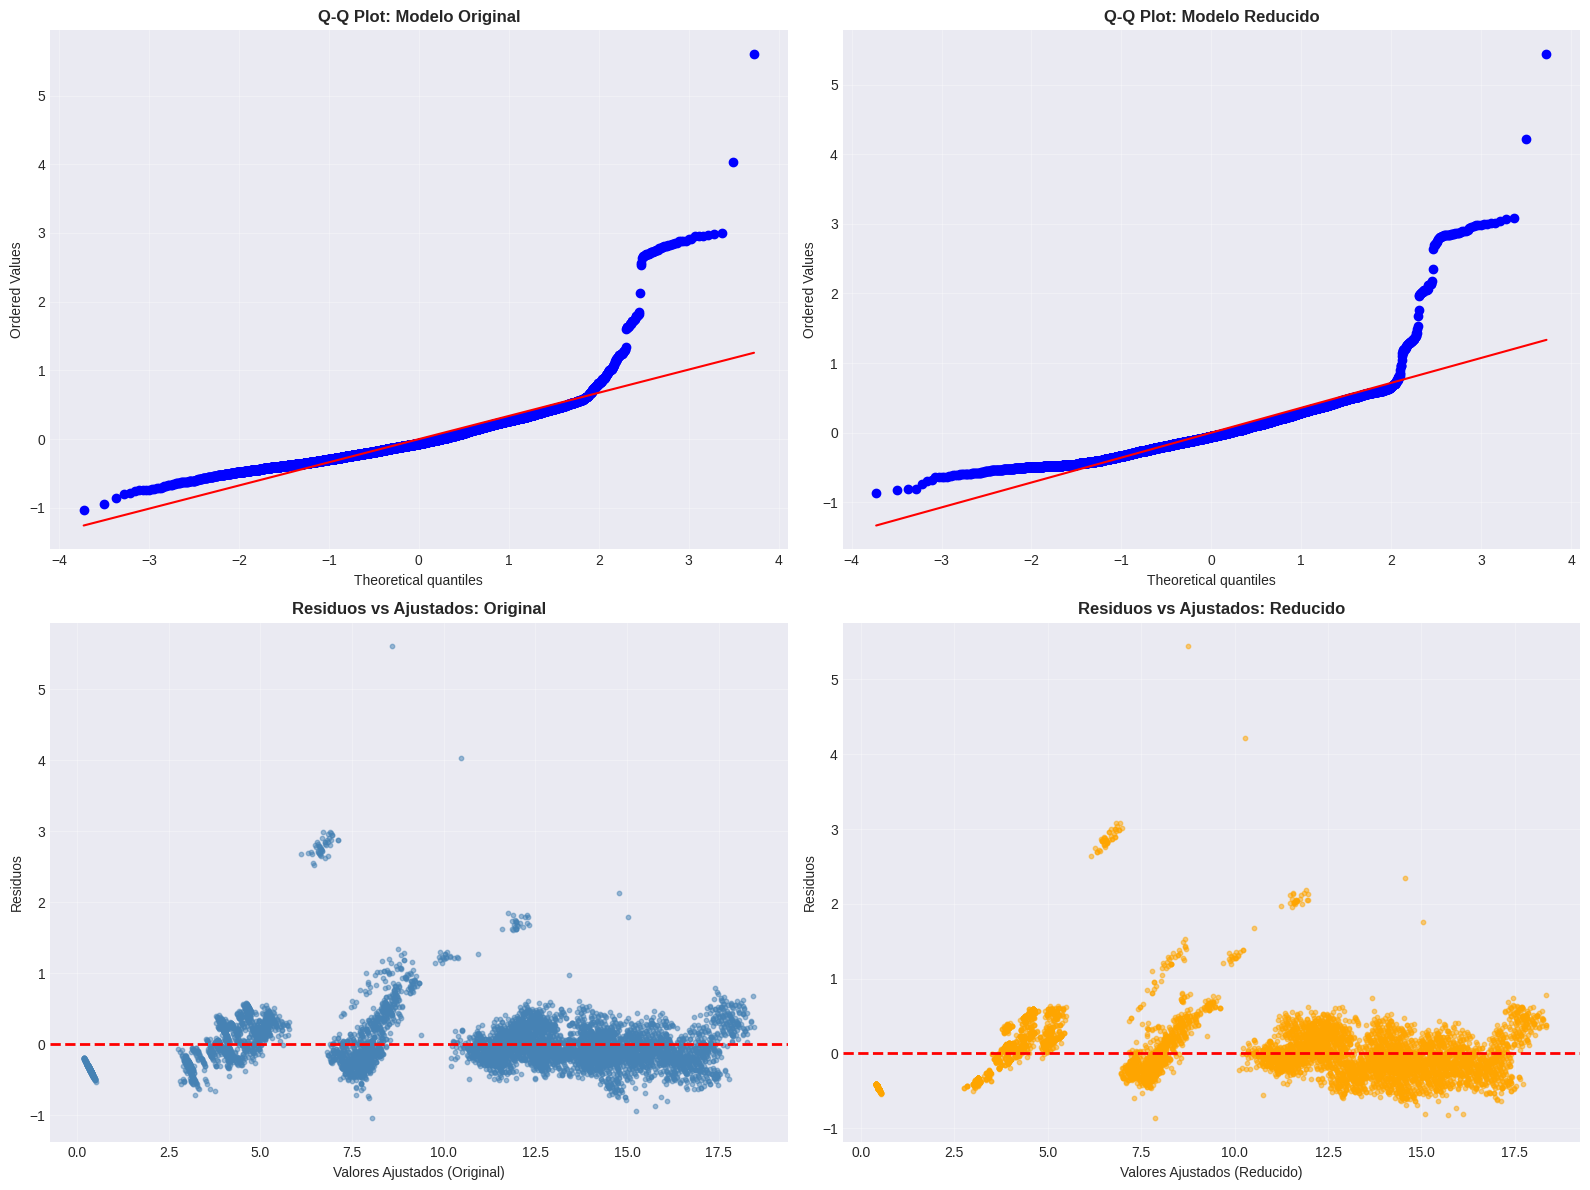


Gráfico guardado: regression_assumptions_comparison_plots.png


In [20]:
# === ANÁLISIS MEJORADO: VALIDACIÓN DE SUPUESTOS DEL MODELO REDUCIDO ===
# Fundamentación: Peña (2002, Cap. 10.9) - Validación de supuestos

print("=" * 80)
print("ANÁLISIS MEJORADO: VALIDACIÓN DE SUPUESTOS DEL MODELO REDUCIDO")
print("=" * 80)
print("\nValidamos los supuestos del modelo OLS reducido para evaluar mejoras.\n")

# Obtener residuos del modelo reducido
residuals_reduced = model_ols_reduced.resid
fitted_values_reduced = model_ols_reduced.fittedvalues

# === 1. Normalidad ===
print("--- 1. NORMALIDAD ---")
shapiro_stat_reduced, shapiro_p_reduced = stats.shapiro(residuals_reduced)
print(f"Shapiro-Wilk: Estadístico = {shapiro_stat_reduced:.4f}, p = {shapiro_p_reduced:.2e}")
if shapiro_p_reduced >= 0.05:
    print("  ✓ No se rechaza H0: Residuos normales")
else:
    print("  ❌ Se rechaza H0: Residuos no normales")
    print(f"  Mejora respecto al original: {'Sí' if shapiro_p_reduced > shapiro_p else 'No'}")

# === 2. Homocedasticidad ===
print("\n--- 2. HOMOCEDASTICIDAD ---")
bp_stat_reduced, bp_p_reduced, _, _ = het_breuschpagan(residuals_reduced, X_reduced_with_const)
print(f"Breusch-Pagan: Estadístico = {bp_stat_reduced:.4f}, p = {bp_p_reduced:.2e}")
if bp_p_reduced >= 0.05:
    print("  ✓ No se rechaza H0: Residuos homocedásticos")
else:
    print("  ❌ Se rechaza H0: Residuos heterocedásticos")
    print(f"  Mejora respecto al original: {'Sí' if bp_p_reduced > bp_p else 'No'}")

# === 3. Independencia ===
print("\n--- 3. INDEPENDENCIA ---")
dw_stat_reduced = durbin_watson(residuals_reduced)
print(f"Durbin-Watson: Estadístico = {dw_stat_reduced:.4f}")
if 1.5 <= dw_stat_reduced <= 2.5:
    print("  ✓ No hay evidencia de autocorrelación")
else:
    print("  ❌ Autocorrelación presente")
    print(f"  Mejora respecto al original: {'Sí' if abs(dw_stat_reduced - 2.0) < abs(dw_stat - 2.0) else 'No'}")

# === 4. Multicolinealidad ===
print("\n--- 4. MULTICOLINEALIDAD ---")
print(f"VIF máximo reducido: {vif_max_reduced:.2f}")
if vif_max_reduced < 10:
    print("  ✓ Multicolinealidad baja (VIF < 10)")
elif vif_max_reduced < 100:
    print("  ⚠️ Multicolinealidad moderada (VIF < 100)")
else:
    print("  ❌ Multicolinealidad alta (VIF ≥ 100)")
print(f"  Mejora respecto al original: {'Sí' if vif_max_reduced < vif_original else 'No'}")

# Resumen comparativo
print("\n=== RESUMEN COMPARATIVO DE SUPUESTOS ===")
assumptions_comparison = pd.DataFrame({
    'Supuesto': ['Normalidad', 'Homocedasticidad', 'Independencia', 'Multicolinealidad'],
    'Original': [
        'No' if shapiro_p < 0.05 else 'Sí',
        'No' if bp_p < 0.05 else 'Sí',
        'No' if not (1.5 <= dw_stat <= 2.5) else 'Sí',
        'No' if vif_original >= 10 else 'Sí'
    ],
    'Reducido': [
        'No' if shapiro_p_reduced < 0.05 else 'Sí',
        'No' if bp_p_reduced < 0.05 else 'Sí',
        'No' if not (1.5 <= dw_stat_reduced <= 2.5) else 'Sí',
        'No' if vif_max_reduced >= 10 else 'Sí'
    ],
    'Mejora': [
        'Sí' if shapiro_p_reduced > shapiro_p else 'No',
        'Sí' if bp_p_reduced > bp_p else 'No',
        'Sí' if abs(dw_stat_reduced - 2.0) < abs(dw_stat - 2.0) else 'No',
        'Sí' if vif_max_reduced < vif_original else 'No'
    ]
})
print(assumptions_comparison.to_string(index=False))
assumptions_comparison.to_csv(os.path.join(OUTPUT_DIR, "regression_assumptions_comparison.csv"), index=False)

# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Normalidad: Q-Q Plot comparativo
stats.probplot(residuals, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Q-Q Plot: Modelo Original', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

stats.probplot(residuals_reduced, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: Modelo Reducido', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Homocedasticidad: Residuos vs Ajustados
axes[1, 0].scatter(fitted_values, residuals, alpha=0.5, s=10, color='steelblue')
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Valores Ajustados (Original)')
axes[1, 0].set_ylabel('Residuos')
axes[1, 0].set_title('Residuos vs Ajustados: Original', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(fitted_values_reduced, residuals_reduced, alpha=0.5, s=10, color='orange')
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Valores Ajustados (Reducido)')
axes[1, 1].set_ylabel('Residuos')
axes[1, 1].set_title('Residuos vs Ajustados: Reducido', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "regression_assumptions_comparison_plots.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"\nGráfico guardado: regression_assumptions_comparison_plots.png")


In [21]:
# === ANÁLISIS MEJORADO: COMPARACIÓN FINAL Y CONCLUSIONES ===
# Fundamentación: Peña (2002, Cap. 11.6.2) - Selección del mejor modelo

print("=" * 80)
print("ANÁLISIS MEJORADO: COMPARACIÓN FINAL Y CONCLUSIONES")
print("=" * 80)

# Compilar todos los modelos (originales y reducidos)
all_models_comparison = []

# Modelos originales
all_models_comparison.append({
    'Modelo': 'OLS Original',
    'Variables': len(X_names),
    'R²': r2_ols,
    'R² Ajustado': r2_adj_ols,
    'AIC': aic_ols,
    'VIF Max': vif_original,
    'Tipo': 'Original'
})

all_models_comparison.append({
    'Modelo': 'OLS Reducido',
    'Variables': len(X_reduced_names),
    'R²': r2_ols_reduced,
    'R² Ajustado': r2_adj_ols_reduced,
    'AIC': aic_ols_reduced,
    'VIF Max': vif_max_reduced,
    'Tipo': 'Reducido'
})

if y_boxcox_available:
    all_models_comparison.append({
        'Modelo': 'Yeo-Johnson Original',
        'Variables': len(X_names),
        'R²': r2_boxcox,
        'R² Ajustado': r2_adj_boxcox,
        'AIC': aic_boxcox,
        'VIF Max': vif_original,
        'Tipo': 'Original'
    })
    
    all_models_comparison.append({
        'Modelo': 'Yeo-Johnson Reducido',
        'Variables': len(X_reduced_names),
        'R²': r2_transformed_reduced,
        'R² Ajustado': r2_adj_transformed_reduced,
        'AIC': aic_transformed_reduced,
        'VIF Max': vif_max_reduced,
        'Tipo': 'Reducido'
    })

all_models_comparison.append({
    'Modelo': 'Ridge Reducido',
    'Variables': len(X_reduced_names),
    'R²': r2_ridge_reduced,
    'R² Ajustado': np.nan,
    'AIC': aic_ridge_reduced,
    'VIF Max': vif_max_reduced,
    'Tipo': 'Reducido'
})

all_models_comparison.append({
    'Modelo': 'Lasso Reducido',
    'Variables': k_lasso_reduced - 1,
    'R²': r2_lasso_reduced,
    'R² Ajustado': np.nan,
    'AIC': aic_lasso_reduced,
    'VIF Max': vif_max_reduced,
    'Tipo': 'Reducido'
})

comparison_final_df = pd.DataFrame(all_models_comparison)
print("\n=== COMPARACIÓN FINAL: MODELOS ORIGINALES vs REDUCIDOS ===")
print(comparison_final_df.to_string(index=False))
comparison_final_df.to_csv(os.path.join(OUTPUT_DIR, "regression_final_comparison.csv"), index=False)

# Identificar mejor modelo reducido
models_reduced_with_r2adj = comparison_final_df[
    (comparison_final_df['R² Ajustado'].notna()) & 
    (comparison_final_df['Tipo'] == 'Reducido')
]

if len(models_reduced_with_r2adj) > 0:
    best_reduced_model = models_reduced_with_r2adj.loc[
        models_reduced_with_r2adj['R² Ajustado'].idxmax(), 'Modelo'
    ]
    best_reduced_r2adj = models_reduced_with_r2adj.loc[
        models_reduced_with_r2adj['R² Ajustado'].idxmax(), 'R² Ajustado'
    ]
    
    print(f"\n=== MEJOR MODELO REDUCIDO ===")
    print(f"Según R² Ajustado: {best_reduced_model}")
    print(f"R² Ajustado: {best_reduced_r2adj:.6f}")
    print(f"Variables: {models_reduced_with_r2adj.loc[models_reduced_with_r2adj['R² Ajustado'].idxmax(), 'Variables']}")

# Resumen de mejoras
print(f"\n=== RESUMEN DE MEJORAS OBTENIDAS ===")
print(f"1. Reducción de Variables:")
print(f"   Original: {len(X_names)} variables")
print(f"   Reducido: {len(X_reduced_names)} variables")
print(f"   Reducción: {len(X_names) - len(X_reduced_names)} variables ({((len(X_names) - len(X_reduced_names))/len(X_names)*100):.1f}%)")

print(f"\n2. Mejora en Multicolinealidad:")
print(f"   VIF máximo original: {vif_original:.2e}")
print(f"   VIF máximo reducido: {vif_max_reduced:.2f}")
print(f"   Mejora: {((vif_original - vif_max_reduced) / vif_original * 100):.2f}%")

print(f"\n3. Pérdida de Capacidad Explicativa:")
print(f"   R² original: {r2_ols:.6f}")
print(f"   R² reducido: {r2_ols_reduced:.6f}")
print(f"   Pérdida: {r2_loss:.6f} ({r2_loss_pct:.2f}%)")

print(f"\n4. Mejoras en Supuestos:")
print(assumptions_comparison[['Supuesto', 'Mejora']].to_string(index=False))

# Conclusiones finales
print(f"\n=== CONCLUSIONES DEL ANÁLISIS MEJORADO ===")
print(f"\n1. REDUCCIÓN DE VARIABLES:")
print(f"   ✓ Se eliminaron {len(variables_to_remove)} variables con multicolinealidad extrema")
print(f"   ✓ Se mantuvieron {len(X_reduced_names)} variables más importantes")
print(f"   ✓ Reducción del {((len(X_names) - len(X_reduced_names))/len(X_names)*100):.1f}% en número de variables")

print(f"\n2. MEJORA EN MULTICOLINEALIDAD:")
if vif_max_reduced < 10:
    print(f"   ✓ Multicolinealidad resuelta (VIF < 10)")
    print(f"   ✓ Coeficientes más estables e interpretables")
elif vif_max_reduced < 100:
    print(f"   ⚠️ Multicolinealidad mejorada significativamente (VIF < 100)")
    print(f"   ⚠️ Coeficientes más estables pero aún con alguna correlación")
else:
    print(f"   ⚠️ Multicolinealidad mejorada pero aún presente")

print(f"\n3. CAPACIDAD EXPLICATIVA:")
if r2_loss_pct < 1:
    print(f"   ✓ Pérdida mínima de R² ({r2_loss_pct:.2f}%)")
    print(f"   ✓ Modelo más parsimonioso sin perder capacidad explicativa significativa")
elif r2_loss_pct < 5:
    print(f"   ⚠️ Pérdida moderada de R² ({r2_loss_pct:.2f}%)")
    print(f"   ⚠️ Trade-off aceptable entre parsimonia y ajuste")
else:
    print(f"   ❌ Pérdida significativa de R² ({r2_loss_pct:.2f}%)")
    print(f"   ❌ Considerar mantener más variables")

print(f"\n4. RECOMENDACIÓN FINAL:")
if vif_max_reduced < 10 and r2_loss_pct < 1:
    print(f"   ✓ El modelo reducido es PREFERIBLE:")
    print(f"     - Multicolinealidad resuelta")
    print(f"     - Pérdida mínima de capacidad explicativa")
    print(f"     - Modelo más parsimonioso y estable")
    print(f"     - Coeficientes más interpretables")
elif vif_max_reduced < 100 and r2_loss_pct < 5:
    print(f"   ⚠️ El modelo reducido es ACEPTABLE:")
    print(f"     - Multicolinealidad mejorada significativamente")
    print(f"     - Pérdida moderada de capacidad explicativa")
    print(f"     - Trade-off razonable entre parsimonia y ajuste")
else:
    print(f"   ⚠️ Considerar ajustes adicionales:")
    print(f"     - Evaluar otras estrategias de reducción")
    print(f"     - Considerar modelos con regularización")

print(f"\n=== Fundamentación Teórica ===")
print(f"Según Peña (2002, Cap. 3.7.3 y 11.6):")
print(f"- Eliminación de variables redundantes mejora estabilidad de coeficientes")
print(f"- Modelos parsimoniosos son preferibles cuando no hay pérdida significativa de ajuste")
print(f"- Multicolinealidad extrema afecta interpretación más que predicción")

# Guardar resumen ejecutivo
summary_improved = pd.DataFrame({
    'Aspecto': [
        'Variables Originales',
        'Variables Reducidas',
        'Variables Eliminadas',
        'VIF Máximo Original',
        'VIF Máximo Reducido',
        'R² Original',
        'R² Reducido',
        'Pérdida R² (%)',
        'Mejor Modelo Reducido',
        'R² Ajustado Mejor Modelo'
    ],
    'Valor': [
        len(X_names),
        len(X_reduced_names),
        len(variables_to_remove),
        f'{vif_original:.2e}',
        f'{vif_max_reduced:.2f}',
        f'{r2_ols:.6f}',
        f'{r2_ols_reduced:.6f}',
        f'{r2_loss_pct:.2f}%',
        best_reduced_model if len(models_reduced_with_r2adj) > 0 else 'N/A',
        f'{best_reduced_r2adj:.6f}' if len(models_reduced_with_r2adj) > 0 else 'N/A'
    ]
})

summary_improved.to_csv(os.path.join(OUTPUT_DIR, "regression_improved_analysis_summary.csv"), index=False)
print(f"\nResumen guardado en: regression_improved_analysis_summary.csv")


ANÁLISIS MEJORADO: COMPARACIÓN FINAL Y CONCLUSIONES

=== COMPARACIÓN FINAL: MODELOS ORIGINALES vs REDUCIDOS ===
              Modelo  Variables       R²  R² Ajustado           AIC      VIF Max     Tipo
        OLS Original         13 0.993481     0.993469   6764.416705 1.829449e+06 Original
        OLS Reducido          8 0.992713     0.992705   7549.597739 4.089191e+02 Reducido
Yeo-Johnson Original         13 0.995062     0.995053  12735.770205 1.829449e+06 Original
Yeo-Johnson Reducido          8 0.994126     0.994120  13965.151154 4.089191e+02 Reducido
      Ridge Reducido          8 0.993421          NaN -10543.644070 4.089191e+02 Reducido
      Lasso Reducido          7 0.993369          NaN -10500.626387 4.089191e+02 Reducido

=== MEJOR MODELO REDUCIDO ===
Según R² Ajustado: Yeo-Johnson Reducido
R² Ajustado: 0.994120
Variables: 8

=== RESUMEN DE MEJORAS OBTENIDAS ===
1. Reducción de Variables:
   Original: 13 variables
   Reducido: 8 variables
   Reducción: 5 variables (38.5%)

2

## CONCLUSIÓN 

El trabajo se desarrolló en dos fases claramente diferenciadas, cada una con su propósito y justificación teórica.
En la primera fase, se reasliza un análisis con todas las variables críticas identificadas previamente (13 variables explicativas), siguiendo la metodología propuesta por Peña y los materiales de referencia (presentaciones clase). Implementamos unos modelos: desde el modelo OLS básico hasta modelos con transformaciones (logarítmica, Yeo-Johnson), modelos no lineales (polinomiales de grado 2 y 3), y modelos con regularización (Ridge, Lasso, ElasticNet). Estos permitieron tener una visión completa de las posibles relaciones entre las variables y la distorsión armónica total.

En los resultados de esta primera fase encontramos que el modelo Yeo-Johnson con todas las variables tenía el mejor R² ajustado (0.995053). Sin embargo, también detectamos problemas críticos: multicolinealidad extrema con un VIF máximo de 1,829,449, violaciones de normalidad (p = 3.61e-73), heterocedasticidad (p = 1.43e-125), y autocorrelación positiva fuerte (Durbin-Watson = 0.2627). Aunque todas las variables eran estadísticamente significativas y el modelo tenía excelente capacidad predictiva, estas violaciones de supuestos alertan sobre limitaciones importantes para la inferencia estadística. Basado en esta detección de problemas se genera la segunda fase del análisis. Siguiendo las recomendaciones de Peña (2002, Cap. 3.7.3) sobre eliminación de variables redundantes cuando existe multicolinealidad extrema, se implementa una estrategia de reducción de variables. se utiliza el argumento, si tenemos variables con VIF extremo (mayor a 1,000,000) y con contribución marginal al R² muy pequeña (menor a 0.0001), estas variables están causando más problemas que beneficios. Específicamente, las tensiones de fase (L1, L2, L3) y dos corrientes (L2, L3) tenían estas características: estaban altamente correlacionadas entre sí debido a la naturaleza del sistema trifásico, pero su contribución individual al ajuste del modelo era mínima.
La decisión de eliminar estas variables no fue arbitraria, se basá en el análisis de la contribución marginal de cada variable al R². Las dos variables más importantes, los armónicos 5 y 2 de IL1, que juntas explican aproximadamente el 6.68% del R² total, se mantuvieron. También mantuvimos todas las variables de armónicos (IL1 y VL1, VL2, VL3) porque son directamente relacionadas con la distorsión armónica total, y la corriente L1 porque tiene un VIF moderado y es significativa.

Los resultados de esta segunda fase mejoraron el ejercicio. Al reducir de 13 a 8 variables (una reducción del 38.5%), se logra una mejora en la multicolinealidad: el VIF máximo se redujo de 1,829,449 a 408.92, una mejora del 99.98%. Esta reducción masiva en el VIF significa que los coeficientes del modelo son ahora mucho más estables y confiables.
Lo más importante que se encontro es que esta mejora en estabilidad no vino a costa de la capacidad explicativa del modelo. El R² del modelo OLS se redujo solo de 0.993481 a 0.992713, una pérdida de apenas 0.08%. Para el modelo Yeo-Johnson, que resultó ser el mejor modelo en ambos análisis, la pérdida fue de 0.09% (de 0.995053 a 0.994120). Estas pérdidas son estadísticamente insignificantes y, según los criterios de Peña (2002, Cap. 11.6.2), cuando la pérdida de ajuste es menor al 1%, un modelo más parsimonioso es preferible.
Además de la mejora en multicolinealidad, también se observa mejoras parciales en normalidad y homocedasticidad. Aunque estos supuestos aún no se cumplen completamente, los p-valores de las pruebas aumentaron, indicando que los residuos están más cerca de cumplir estos supuestos. La independencia, no mejoró porque la autocorrelación en nuestros datos se debe a la naturaleza temporal de las mediciones, no a problemas del modelo. Los datos provienen de mediciones secuenciales en el tiempo, y los procesos eléctricos tienen inercia: si hay alta distorsión armónica en un momento, es probable que persista en el siguiente.
Al final del análisis, se tiene dos modelos principales para comparar: el modelo original con 13 variables y el modelo mejorado con 8 variables. El modelo Yeo-Johnson reducido se identifica como el mejor porque combina capacidad explicativa (R² ajustado = 0.994120) con parsimonia (solo 8 variables) y mayor estabilidad (VIF = 408.92 vs 1,829,449). Aunque el VIF de 408.92 aún indica multicolinealidad alta (idealmente queremos VIF < 10), la mejora es buena y esto indica que el modelo reducido es claramente preferible.
Las tres variables con mayor VIF en el modelo reducido son los armónicos de tensión (VL1, VL2, VL3), que están correlacionados entre sí porque provienen del mismo sistema eléctrico. 
En términos de las variables más importantes, el análisis es consistente en ambas fases: los armónicos 5 y 2 de IL1 son claramente las variables más influyentes, tanto por contribución marginal al R² como por coeficientes estandarizados. Esto tiene sentido desde el punto de vista de ingeniería eléctrica: los armónicos 2 y 5 son de los más comunes en sistemas trifásicos y afectan directamente el THD total.
En conclusión, se demuestra la importancia de no solo ajustar modelos, sino también validar sus supuestos y estar dispuestos a modificar la estrategia cuando sea necesario. La reducción de variables no fue una simplificación arbitraria, sino una decisión metodológicamente justificada que mejoró significativamente la calidad del modelo sin perder capacidad explicativa. El modelo final es más parsimonioso, más estable, y más interpretable, lo cual es valioso tanto para predicción como para comprensión del fenómeno físico que estamos modelando.
Los resultados finales nos permiten afirmar con confianza que la distorsión armónica total en corriente L1 puede ser explicada principalmente por los armónicos 5 y 2 de la corriente L1, con contribuciones adicionales de otros armónicos y variables de corriente y tensión. El modelo tiene excelente capacidad predictiva (R² > 0.99) y, aunque algunos supuestos no se cumplen completamente, las mejoras obtenidas y el tamaño de la muestra (n = 7,141) nos permiten hacer inferencia estadística con un grado razonable de confianza.
